# Healthcare Predictive Analytics — Capstone
**Wildcats Analytics Partners | Northwestern MSDS**

Run each cell in order. Only Cell 1 (installs) and Cell 2 (config) need manual attention.

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 — INSTALL DEPENDENCIES  (run once per Colab session)
# ─────────────────────────────────────────────────────────────
!pip install -q kagglehub xgboost powerbiclient plotly


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.9/684.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.5/121.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 39.7 MB/s eta 0:00:00


## Configuration
Fill in your credentials below before running anything else.

In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 2 — CONFIGURATION  ← Fill in before running
# ─────────────────────────────────────────────────────────────

# Google Drive folder where all CSVs will be saved
DRIVE_OUTPUT_PATH = '/content/gdrive/MyDrive/capstone_outputs'

# Dataset slug (no changes needed)
DATASET_SLUG = 'prasad22/healthcare-dataset'

# Power BI: from app.powerbi.com URL after publishing your .pbix
# https://app.powerbi.com/groups/me/reports/20964dbd-27e0-4127-9b77-52ba799ef29d/
POWERBI_GROUP_ID  = "me"  # <-- Fill in from URL above
POWERBI_REPORT_ID = "8c6e1977-7f1b-495e-a5b4-933be0afd2c9" # <-- Fill in from URL above

## Imports & Setup

In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 — ALL IMPORTS (one place, no duplicates)
# ─────────────────────────────────────────────────────────────
import os, json, warnings, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import plotly.graph_objects as go
import plotly.offline as pyo

from sklearn.model_selection      import train_test_split, RandomizedSearchCV
from sklearn.preprocessing        import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.impute                import SimpleImputer
from sklearn.compose               import ColumnTransformer
from sklearn.pipeline              import Pipeline
from sklearn.linear_model          import LinearRegression, LogisticRegression
from sklearn.tree                  import DecisionTreeRegressor
from sklearn.ensemble              import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics               import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc, confusion_matrix
)
from xgboost import XGBRegressor, XGBClassifier

import kagglehub
from google.colab import drive, output as colab_output

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})
ACCENT = '#4C72B0'
pyo.init_notebook_mode(connected=True)

# Mount Google Drive
drive.mount('/content/gdrive')
os.makedirs(DRIVE_OUTPUT_PATH, exist_ok=True)
print('✓ All imports loaded')
print(f'✓ Google Drive mounted — outputs → {DRIVE_OUTPUT_PATH}')


Mounted at /content/gdrive
✓ All imports loaded
✓ Google Drive mounted — outputs → /content/gdrive/MyDrive/capstone_outputs


## Data Loading
Downloads once and keeps `df_raw` untouched throughout. Each section works from `df_raw`.

In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 — DOWNLOAD & LOAD DATASET
# ─────────────────────────────────────────────────────────────
dataset_dir = kagglehub.dataset_download(DATASET_SLUG)
CSV_PATH    = os.path.join(dataset_dir, 'healthcare_dataset.csv')

df_raw = pd.read_csv(CSV_PATH)
# Deduplicate once
df_raw = df_raw.drop_duplicates().copy()

print(f'✓ Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'  Missing values : {df_raw.isnull().sum().sum()}')
df_raw.head()


100%|██████████| 2.91M/2.91M [00:00<00:00, 32.5MB/s]

Extracting files...


✓ Dataset loaded: 54,966 rows × 15 columns
  Missing values : 0


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Exploratory Data Analysis (EDA)

  HEALTHCARE DATASET — EDA
  Shape        : (54966, 19)
  Missing vals : 0
  Duplicates   : 0



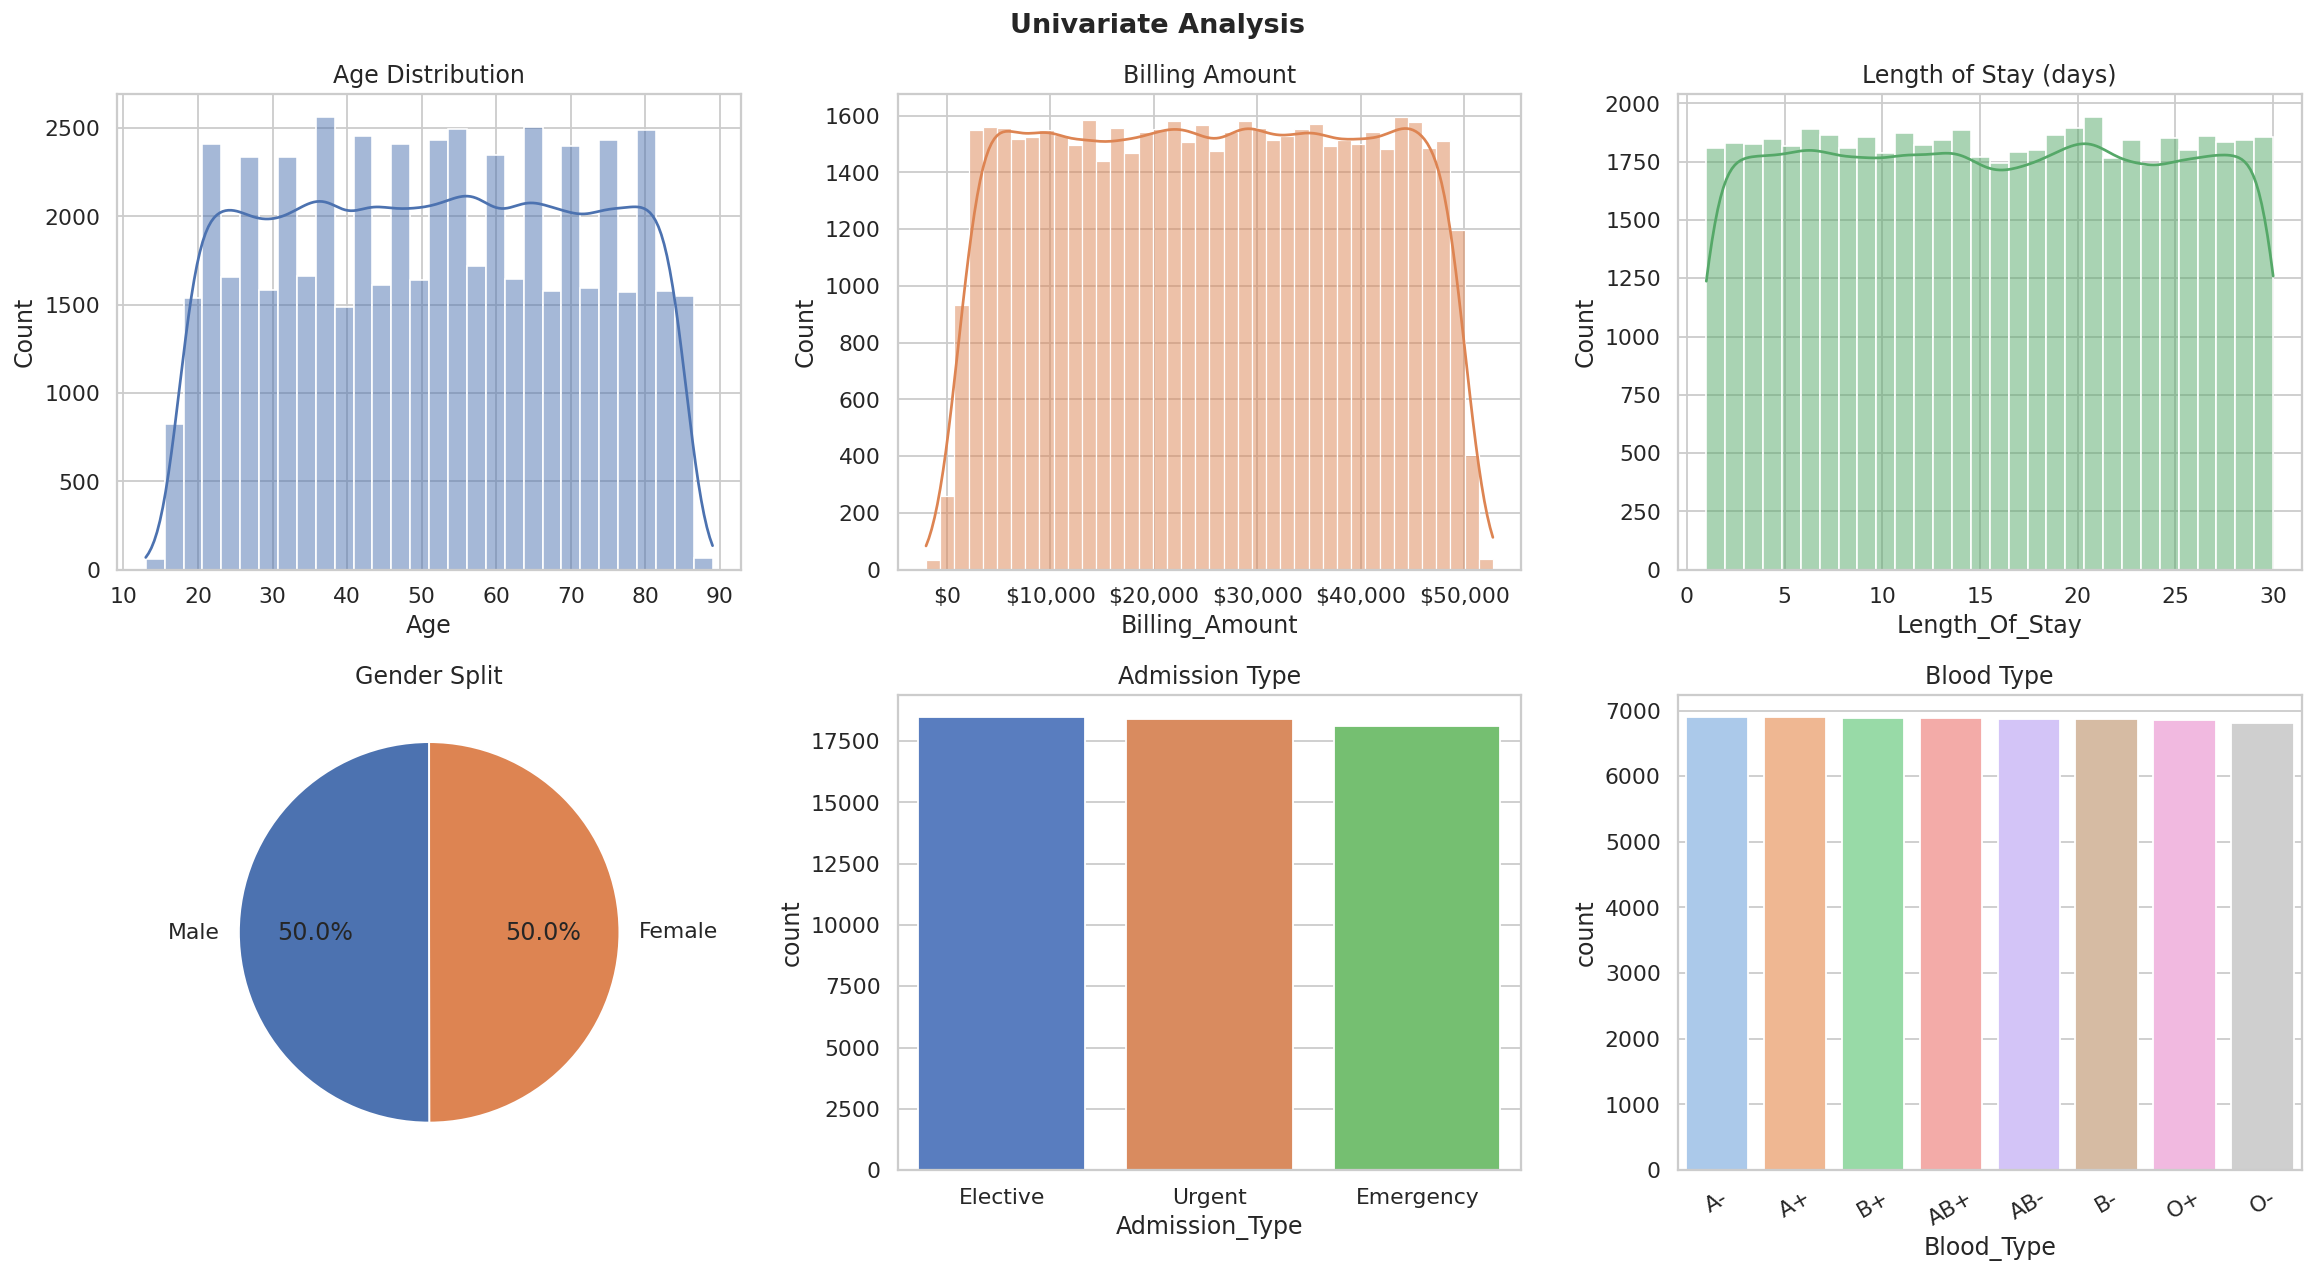

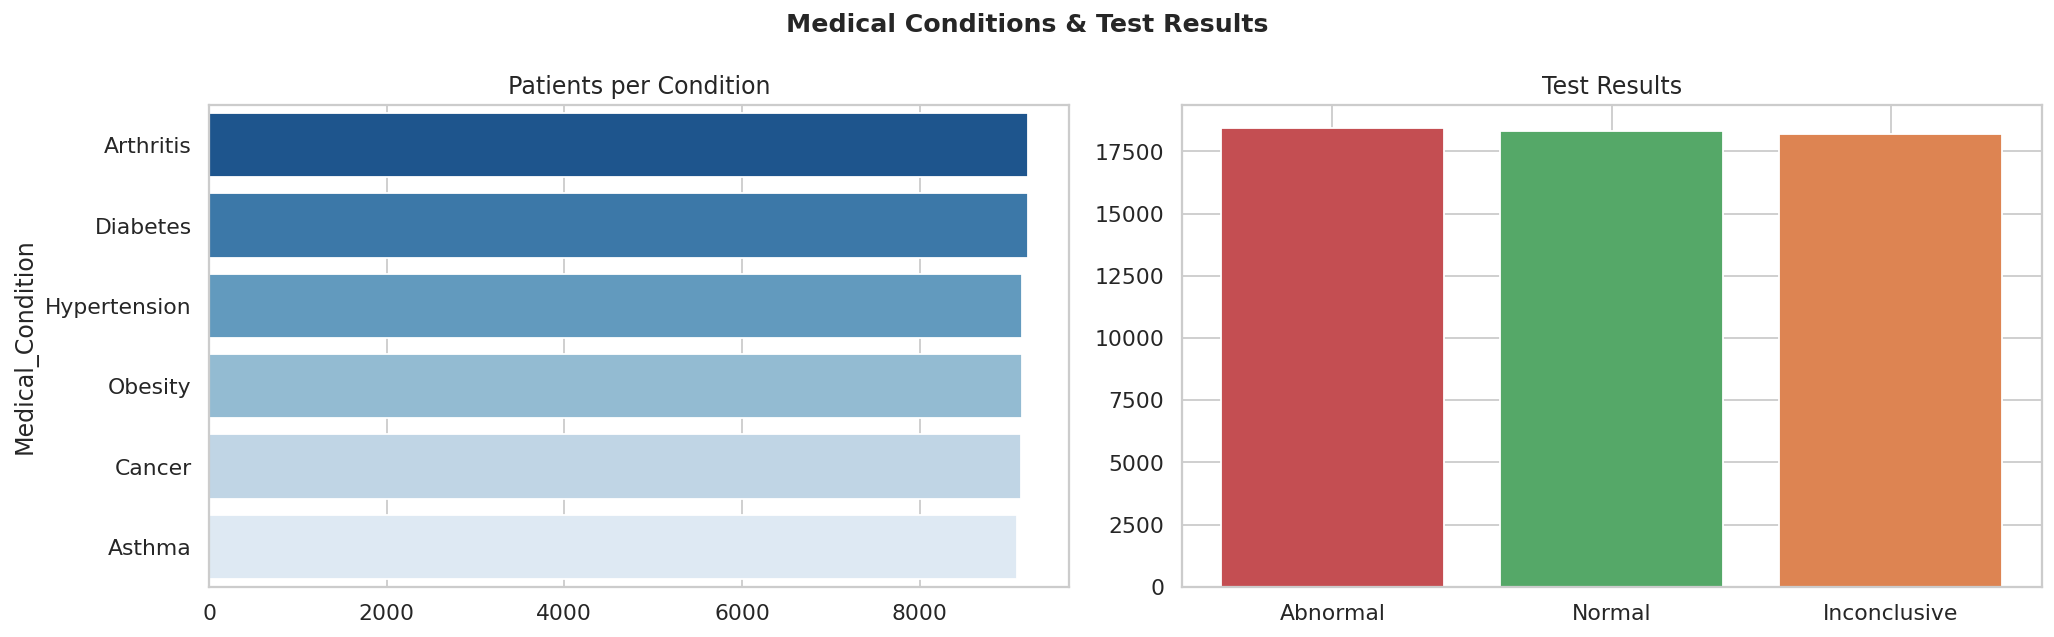

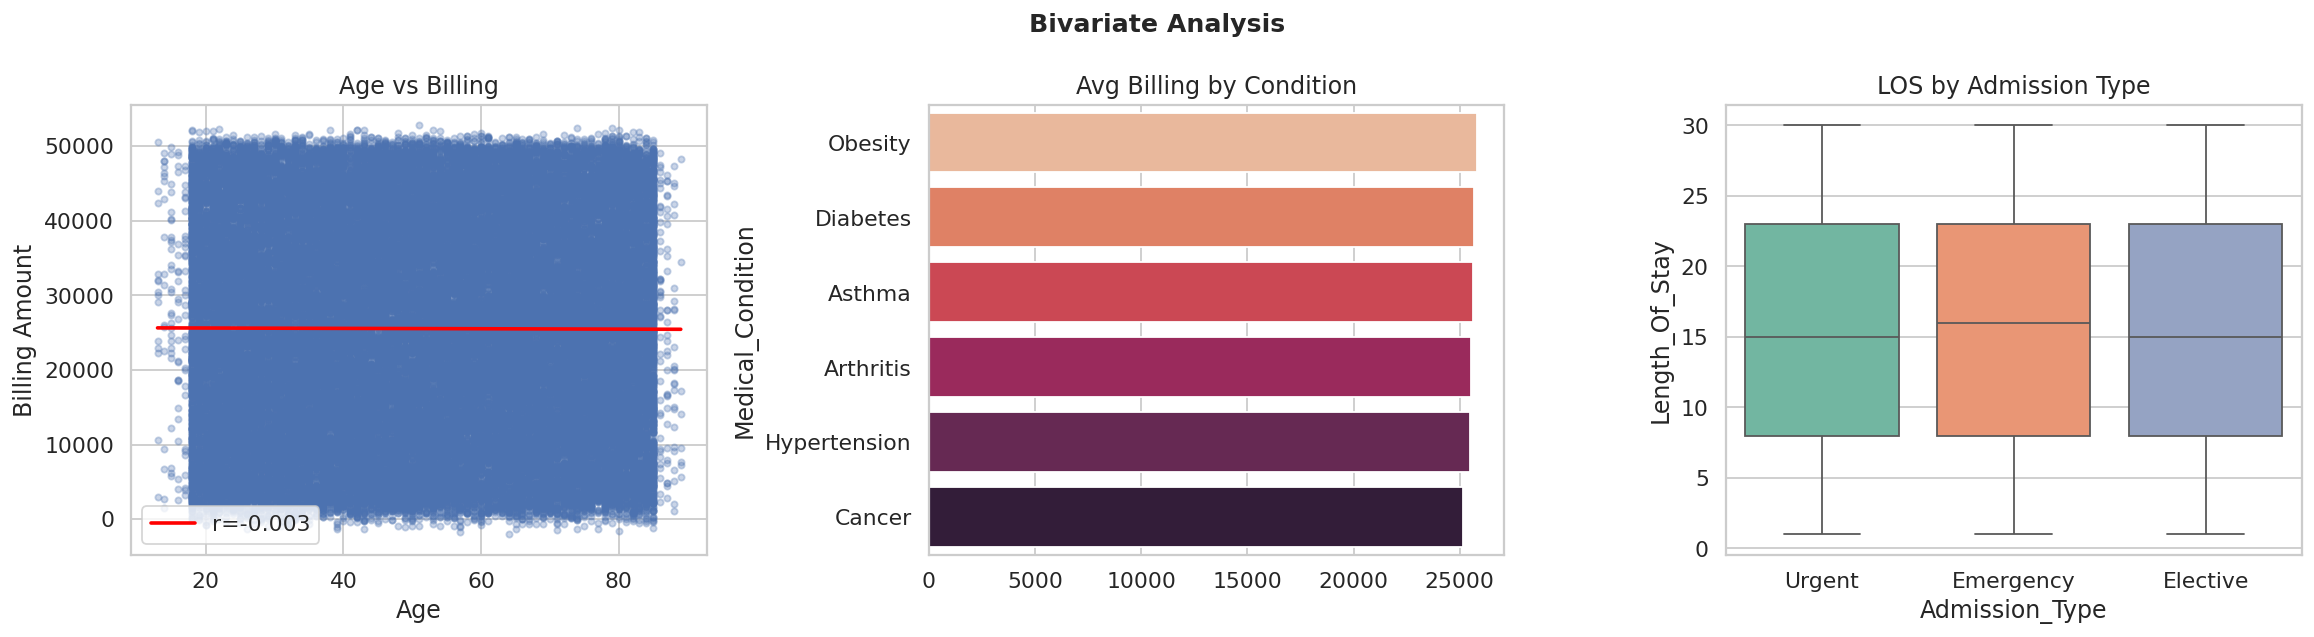

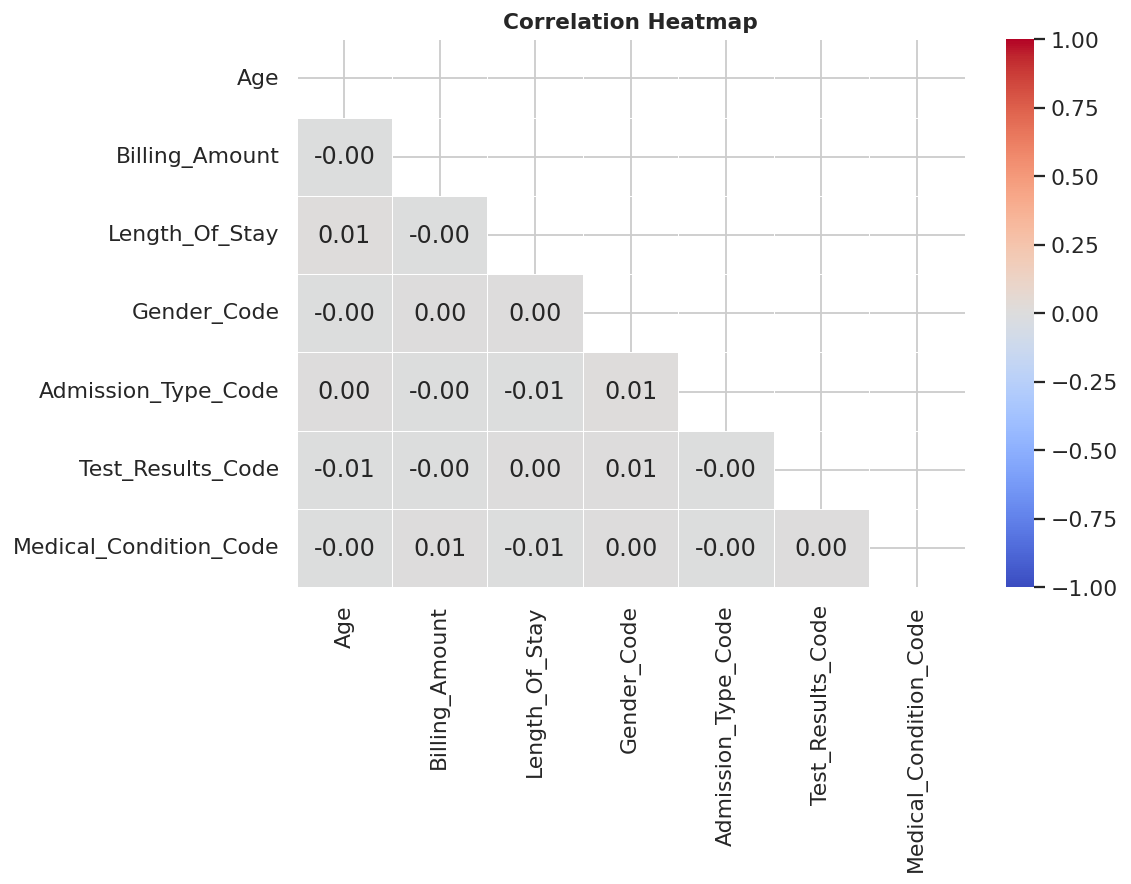

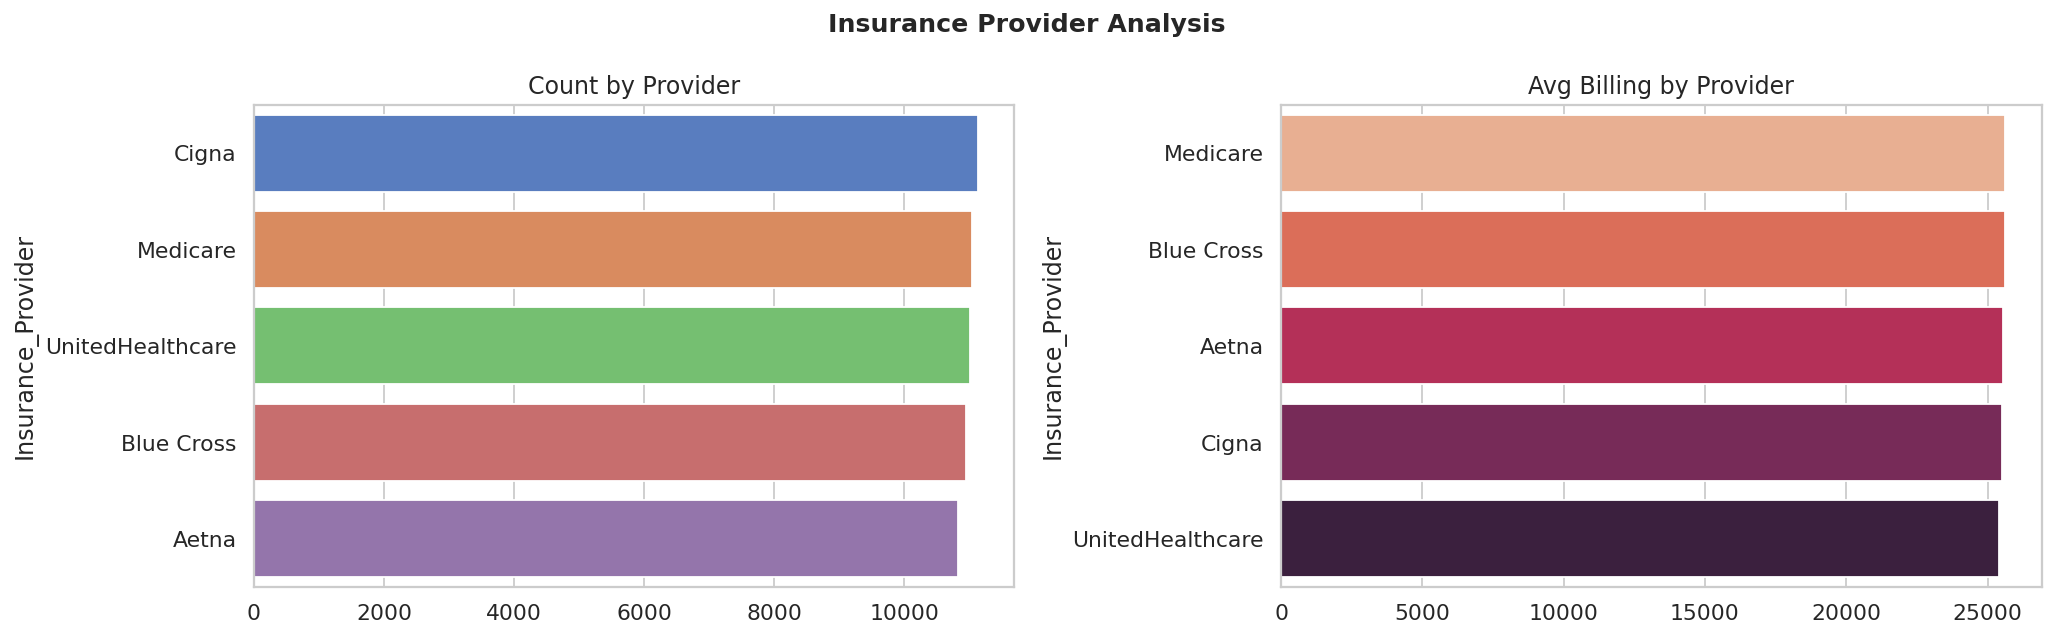


  KEY INSIGHTS SUMMARY
  Records           : 54,966
  Age range         : 13 – 89 (mean 51.5)
  Avg billing       : $25,544.31
  Median billing    : $25,542.75
  Avg LOS           : 15.5 days
  Top condition     : Arthritis
  Top medication    : Lipitor


In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 5 — EDA
# Works from df_raw — does NOT modify the shared dataframe
# ─────────────────────────────────────────────────────────────
df_eda = df_raw.copy()

# Normalise column names for EDA only
df_eda.columns = df_eda.columns.str.strip().str.title().str.replace(' ', '_')
for col in ['Date_Of_Admission', 'Discharge_Date']:
    df_eda[col] = pd.to_datetime(df_eda[col], errors='coerce')
df_eda['Length_Of_Stay']  = (df_eda['Discharge_Date'] - df_eda['Date_Of_Admission']).dt.days
df_eda['Admission_Year']  = df_eda['Date_Of_Admission'].dt.year
df_eda['Admission_Month'] = df_eda['Date_Of_Admission'].dt.month
bins   = [0, 18, 35, 50, 65, 120]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
df_eda['Age_Group'] = pd.cut(df_eda['Age'], bins=bins, labels=labels)

print('=' * 60)
print('  HEALTHCARE DATASET — EDA')
print('=' * 60)
print(f'  Shape        : {df_eda.shape}')
print(f'  Missing vals : {df_eda.isnull().sum().sum()}')
print(f'  Duplicates   : {df_eda.duplicated().sum()}')
print()

# ── 1. Univariate ──────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Univariate Analysis', fontsize=15, fontweight='bold')
sns.histplot(df_eda['Age'], bins=30, kde=True, color=ACCENT, ax=axes[0,0]).set_title('Age Distribution')
sns.histplot(df_eda['Billing_Amount'], bins=40, kde=True, color='#DD8452', ax=axes[0,1]).set_title('Billing Amount')
axes[0,1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
sns.histplot(df_eda['Length_Of_Stay'].dropna(), bins=30, kde=True, color='#55A868', ax=axes[0,2]).set_title('Length of Stay (days)')
gc = df_eda['Gender'].value_counts()
axes[1,0].pie(gc, labels=gc.index, autopct='%1.1f%%', colors=['#4C72B0','#DD8452'], startangle=90)
axes[1,0].set_title('Gender Split')
sns.countplot(data=df_eda, x='Admission_Type', order=df_eda['Admission_Type'].value_counts().index, palette='muted', ax=axes[1,1]).set_title('Admission Type')
sns.countplot(data=df_eda, x='Blood_Type', order=df_eda['Blood_Type'].value_counts().index, palette='pastel', ax=axes[1,2]).set_title('Blood Type')
axes[1,2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig('01_univariate.png', bbox_inches='tight'); plt.show()

# ── 2. Medical Conditions & Test Results ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Medical Conditions & Test Results', fontsize=14, fontweight='bold')
cc = df_eda['Medical_Condition'].value_counts()
sns.barplot(x=cc.values, y=cc.index, palette='Blues_r', ax=axes[0]).set_title('Patients per Condition')
tc = df_eda['Test_Results'].value_counts()
bar_c = ['#55A868' if t=='Normal' else '#C44E52' if t=='Abnormal' else '#DD8452' for t in tc.index]
axes[1].bar(tc.index, tc.values, color=bar_c, edgecolor='white'); axes[1].set_title('Test Results')
plt.tight_layout(); plt.savefig('02_conditions_tests.png', bbox_inches='tight'); plt.show()

# ── 3. Bivariate ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Bivariate Analysis', fontsize=14, fontweight='bold')
axes[0].scatter(df_eda['Age'], df_eda['Billing_Amount'], alpha=0.3, color=ACCENT, s=12)
m,b,r,p,_ = stats.linregress(df_eda['Age'].dropna(), df_eda['Billing_Amount'].dropna())
xl = np.linspace(df_eda['Age'].min(), df_eda['Age'].max(), 100)
axes[0].plot(xl, m*xl+b, color='red', linewidth=2, label=f'r={r:.3f}')
axes[0].set(xlabel='Age', ylabel='Billing Amount', title='Age vs Billing'); axes[0].legend()
ab = df_eda.groupby('Medical_Condition')['Billing_Amount'].mean().sort_values(ascending=False)
sns.barplot(x=ab.values, y=ab.index, palette='rocket_r', ax=axes[1]).set_title('Avg Billing by Condition')
sns.boxplot(data=df_eda, x='Admission_Type', y='Length_Of_Stay', palette='Set2', ax=axes[2]).set_title('LOS by Admission Type')
plt.tight_layout(); plt.savefig('03_bivariate.png', bbox_inches='tight'); plt.show()

# ── 4. Correlation Heatmap ─────────────────────────────────
df_enc = df_eda.copy()
for col in ['Gender','Admission_Type','Test_Results','Medical_Condition']:
    df_enc[col+'_Code'] = pd.Categorical(df_enc[col]).codes
num_cols = ['Age','Billing_Amount','Length_Of_Stay','Gender_Code','Admission_Type_Code','Test_Results_Code','Medical_Condition_Code']
corr = df_enc[num_cols].corr()
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr,dtype=bool)), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('04_heatmap.png', bbox_inches='tight'); plt.show()

# ── 5. Insurance Provider ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16,5))
fig.suptitle('Insurance Provider Analysis', fontsize=14, fontweight='bold')
ic = df_eda['Insurance_Provider'].value_counts()
sns.barplot(x=ic.values, y=ic.index, palette='muted', ax=axes[0]).set_title('Count by Provider')
ib = df_eda.groupby('Insurance_Provider')['Billing_Amount'].mean().sort_values(ascending=False)
sns.barplot(x=ib.values, y=ib.index, palette='rocket_r', ax=axes[1]).set_title('Avg Billing by Provider')
plt.tight_layout(); plt.savefig('05_insurance.png', bbox_inches='tight'); plt.show()

# ── 6. Key Insights Summary ───────────────────────────────
print('\n' + '='*60)
print('  KEY INSIGHTS SUMMARY')
print('='*60)
print(f'  Records           : {len(df_eda):,}')
print(f'  Age range         : {df_eda["Age"].min()} – {df_eda["Age"].max()} (mean {df_eda["Age"].mean():.1f})')
print(f'  Avg billing       : ${df_eda["Billing_Amount"].mean():,.2f}')
print(f'  Median billing    : ${df_eda["Billing_Amount"].median():,.2f}')
print(f'  Avg LOS           : {df_eda["Length_Of_Stay"].mean():.1f} days')
print(f'  Top condition     : {df_eda["Medical_Condition"].value_counts().index[0]}')
print(f'  Top medication    : {df_eda["Medication"].value_counts().index[0]}')
print('='*60)


## Financial Analysis

  FINANCIAL SUMMARY STATISTICS
  Mean billing       : $ 25,544.31
  Median billing     : $ 25,542.75
  Std deviation      : $ 14,208.41
  Min / Max          : $-2,008.49  –  $52,764.28
  Skewness           :    -0.0013
  Avg LOS            :       15.5 days


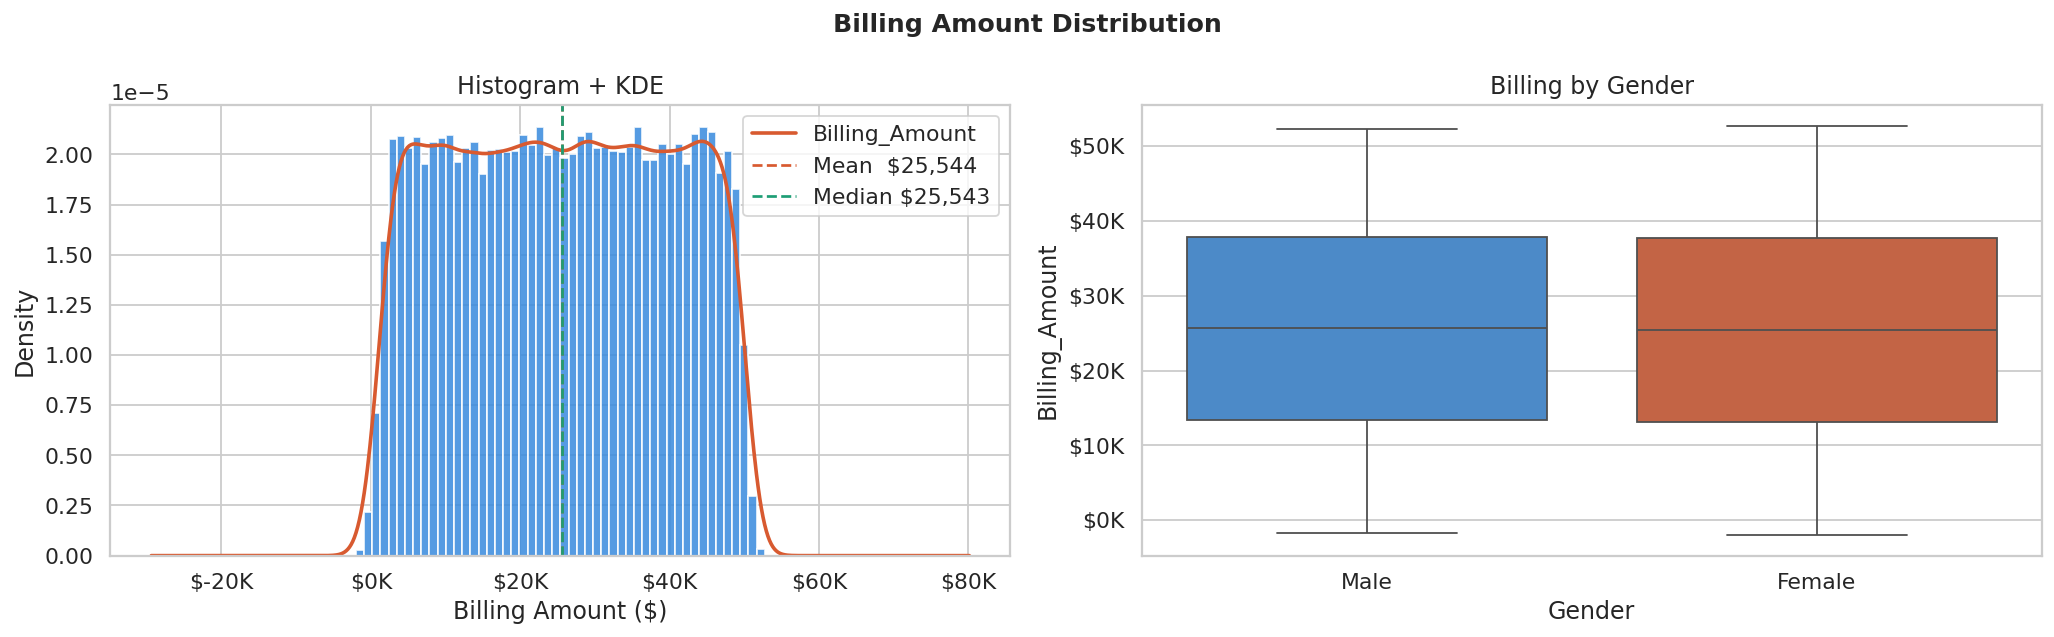

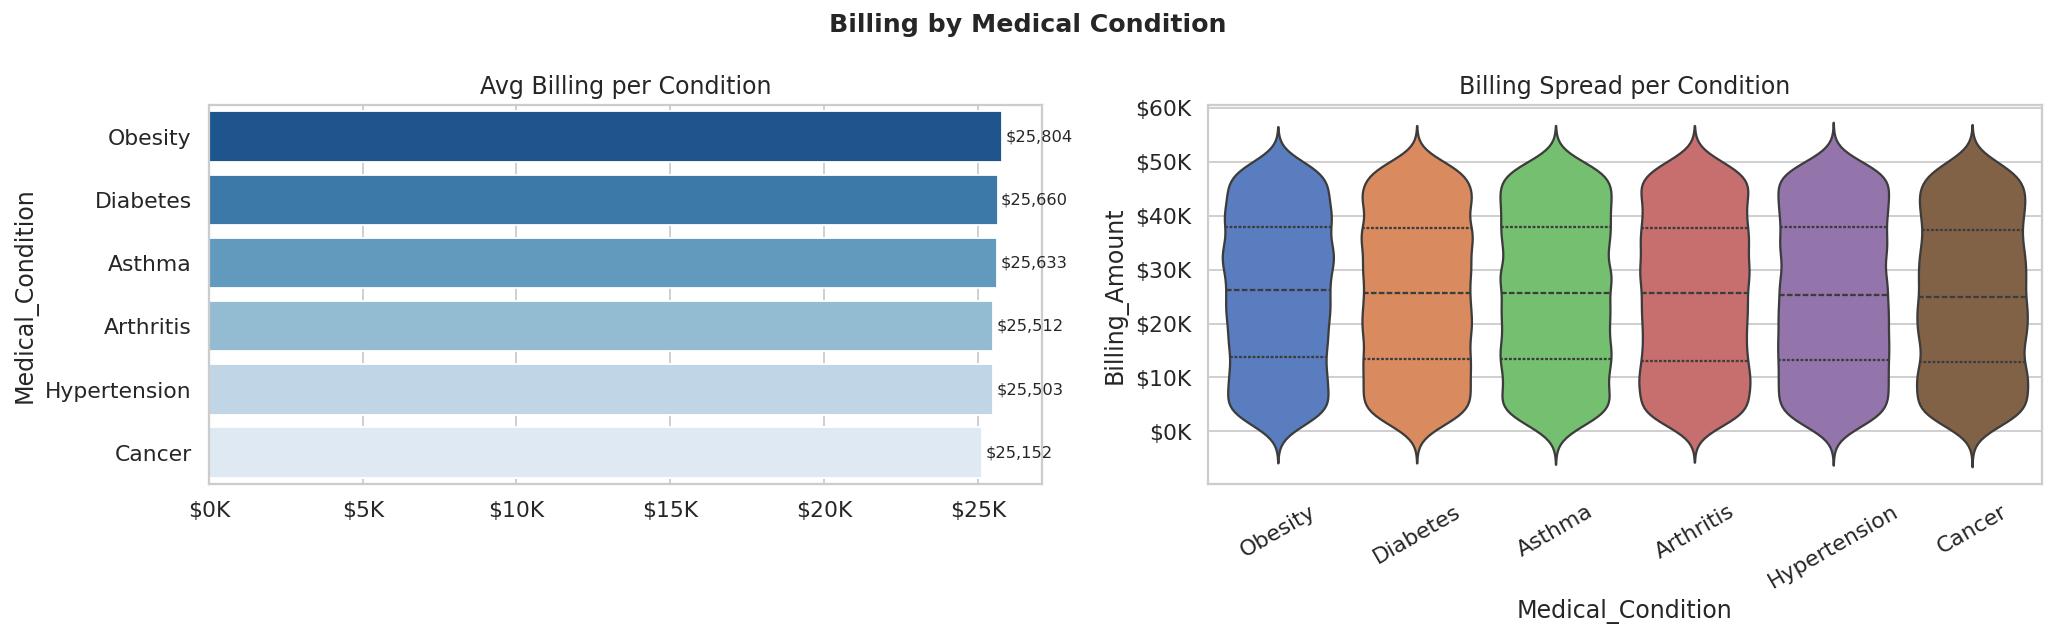

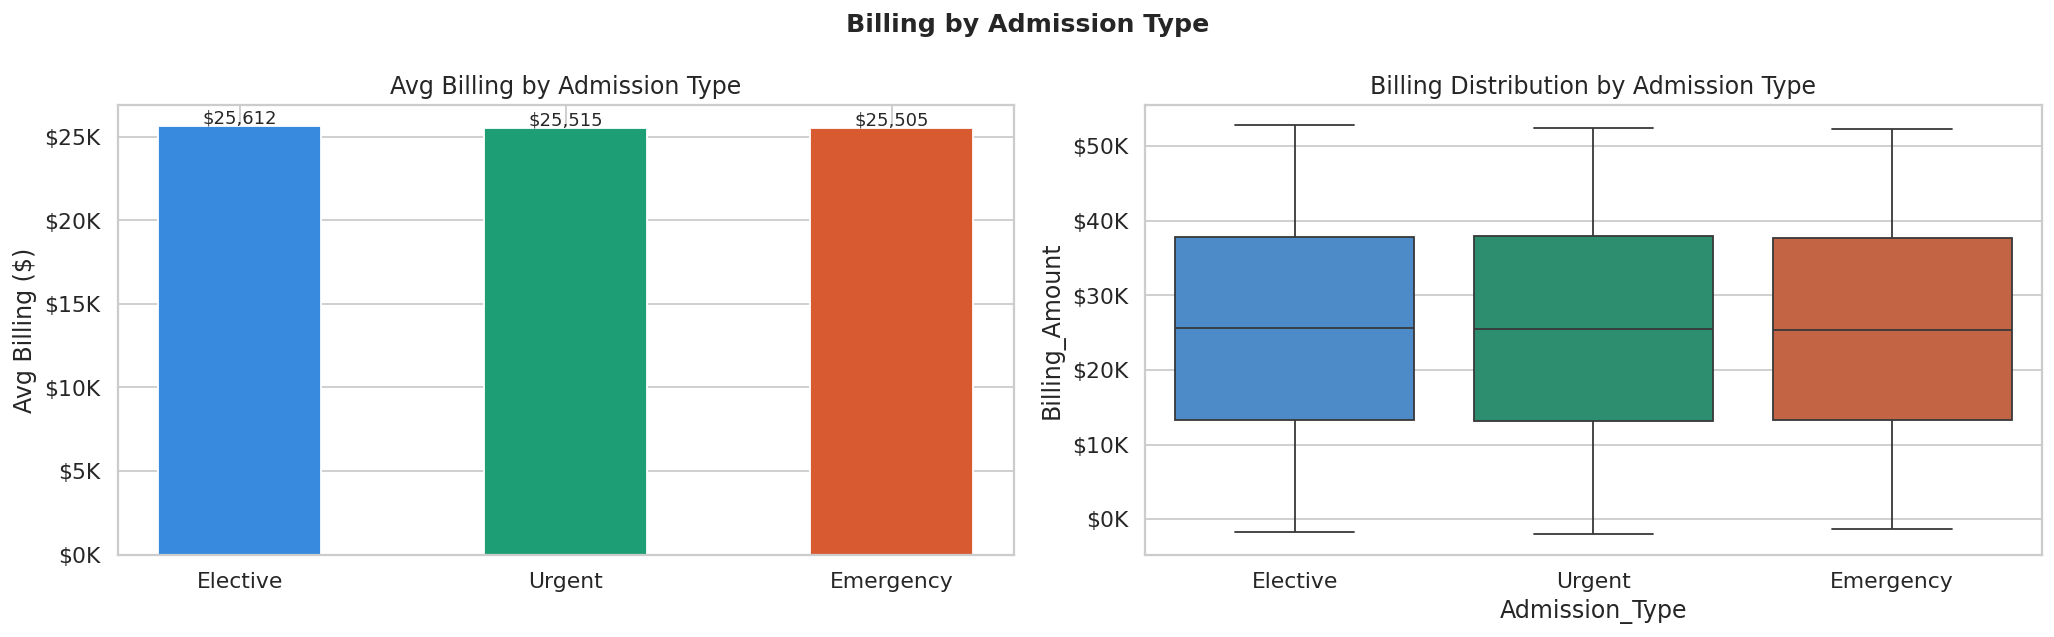

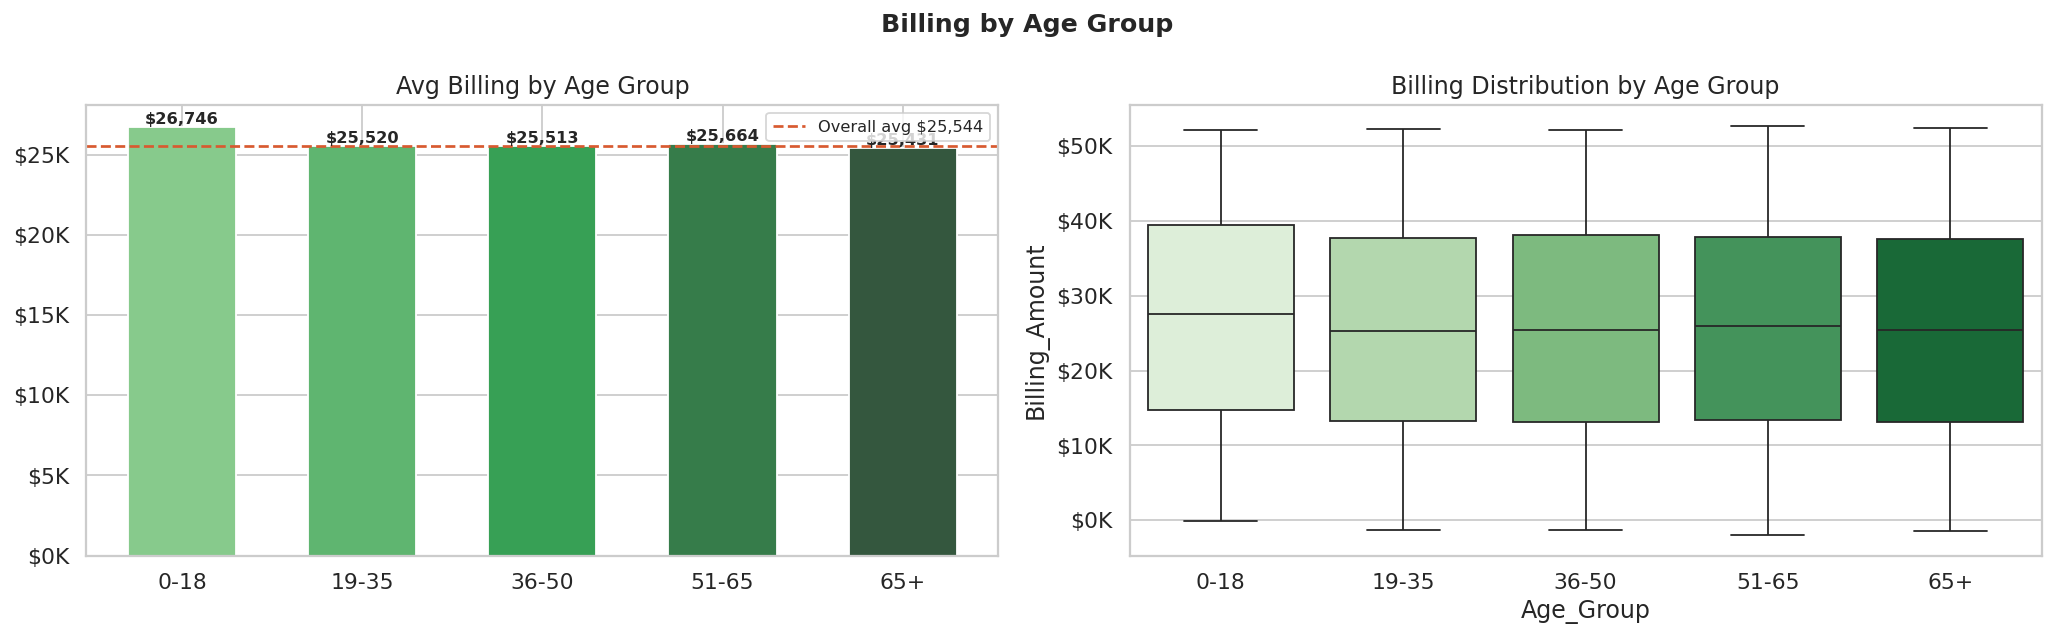

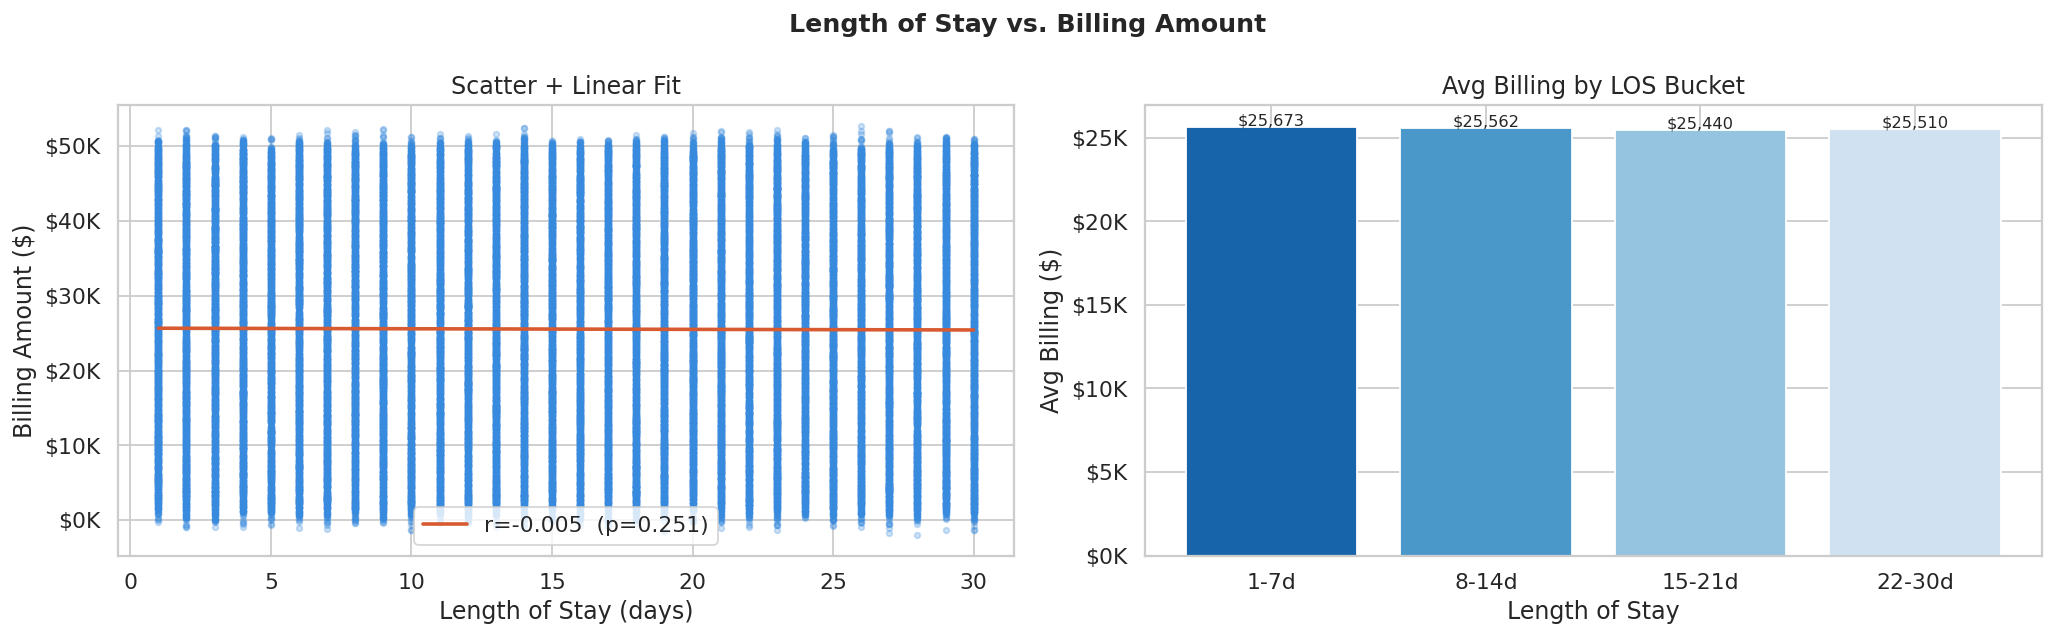

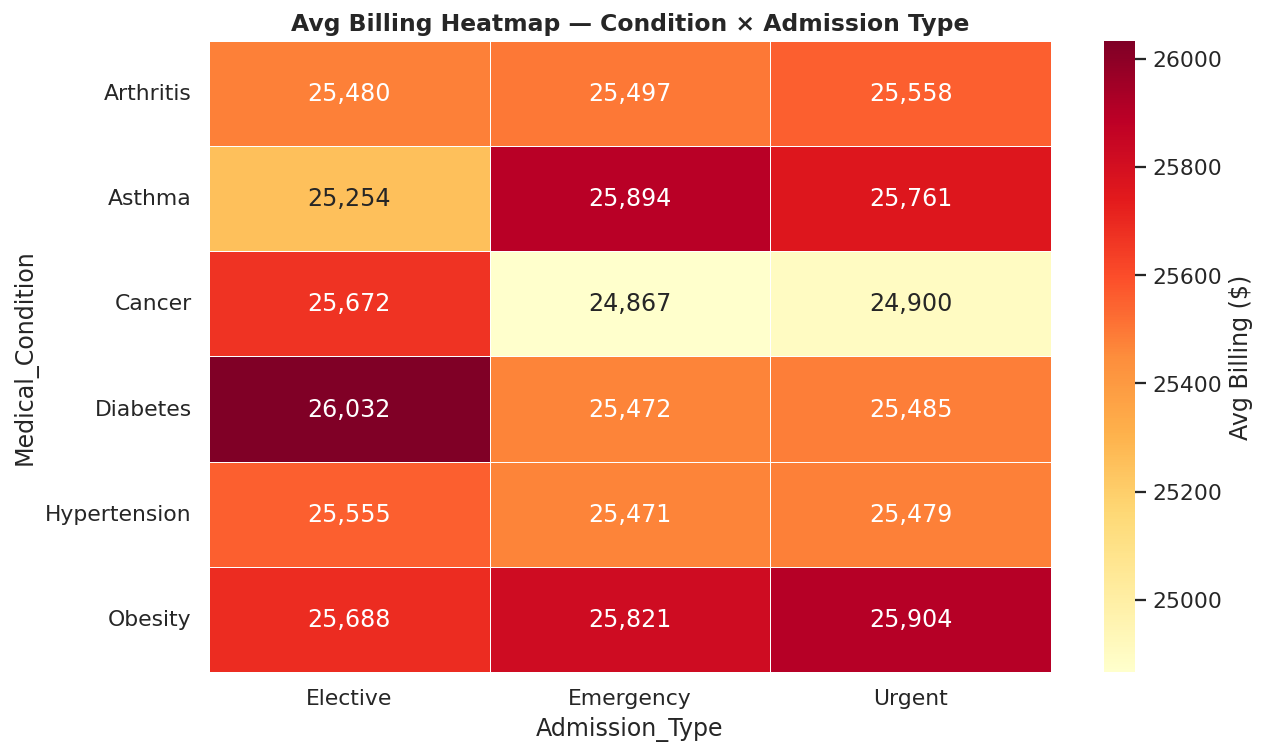


  STATISTICAL TESTS
[ANOVA] Billing across Conditions : F=2.2242, p=0.0490  *significant*
[ANOVA] Billing across Admission  : F=0.3190, p=0.7269  not significant
[T-test] Male vs Female           : t=1.1579, p=0.2469  not significant
[Pearson] LOS ↔ Billing           : r=-0.0049, p=0.2515  not significant


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 6 — FINANCIAL ANALYSIS
# Works from df_raw — does NOT modify the shared dataframe
# ─────────────────────────────────────────────────────────────
df_fin = df_raw.copy()
df_fin.columns = df_fin.columns.str.strip().str.title().str.replace(' ', '_')
for col in ['Date_Of_Admission', 'Discharge_Date']:
    df_fin[col] = pd.to_datetime(df_fin[col], errors='coerce')
df_fin['Length_Of_Stay'] = (df_fin['Discharge_Date'] - df_fin['Date_Of_Admission']).dt.days
bins   = [0, 18, 35, 50, 65, 120]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
df_fin['Age_Group'] = pd.cut(df_fin['Age'], bins=bins, labels=labels)
billing = df_fin['Billing_Amount']

# ── 1. Summary statistics ─────────────────────────────────
print('='*60)
print('  FINANCIAL SUMMARY STATISTICS')
print('='*60)
print(f'  Mean billing       : ${billing.mean():>10,.2f}')
print(f'  Median billing     : ${billing.median():>10,.2f}')
print(f'  Std deviation      : ${billing.std():>10,.2f}')
print(f'  Min / Max          : ${billing.min():,.2f}  –  ${billing.max():,.2f}')
print(f'  Skewness           : {billing.skew():>10.4f}')
print(f'  Avg LOS            : {df_fin["Length_Of_Stay"].mean():>10.1f} days')

# ── 2. Billing distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Billing Amount Distribution', fontsize=14, fontweight='bold')
axes[0].hist(billing, bins=50, color='#378ADD', edgecolor='white', alpha=0.85, density=True)
billing.plot.kde(ax=axes[0], color='#D85A30', linewidth=2)
axes[0].axvline(billing.mean(),   color='#D85A30', linestyle='--', linewidth=1.5, label=f'Mean  ${billing.mean():,.0f}')
axes[0].axvline(billing.median(), color='#1D9E75', linestyle='--', linewidth=1.5, label=f'Median ${billing.median():,.0f}')
axes[0].set_title('Histogram + KDE'); axes[0].set_xlabel('Billing Amount ($)'); axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
sns.boxplot(data=df_fin, x='Gender', y='Billing_Amount', palette=['#378ADD','#D85A30'], ax=axes[1]).set_title('Billing by Gender')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
plt.tight_layout(); plt.savefig('fin_01_distribution.png', bbox_inches='tight'); plt.show()

# ── 3. Billing by medical condition ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Billing by Medical Condition', fontsize=14, fontweight='bold')
ac = df_fin.groupby('Medical_Condition')['Billing_Amount'].mean().sort_values(ascending=False)
sns.barplot(x=ac.values, y=ac.index, palette='Blues_r', ax=axes[0]).set_title('Avg Billing per Condition')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
for i,v in enumerate(ac.values): axes[0].text(v+100, i, f'${v:,.0f}', va='center', fontsize=9)
sns.violinplot(data=df_fin, x='Medical_Condition', y='Billing_Amount', order=ac.index,
               palette='muted', inner='quartile', ax=axes[1]).set_title('Billing Spread per Condition')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig('fin_02_condition_billing.png', bbox_inches='tight'); plt.show()

# ── 4. Billing by admission type ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Billing by Admission Type', fontsize=14, fontweight='bold')
aa = df_fin.groupby('Admission_Type')['Billing_Amount'].mean().sort_values(ascending=False)
ca = {'Emergency':'#D85A30','Elective':'#378ADD','Urgent':'#1D9E75'}
axes[0].bar(aa.index, aa.values, color=[ca.get(k,'#888') for k in aa.index], edgecolor='white', width=0.5)
axes[0].set_title('Avg Billing by Admission Type'); axes[0].set_ylabel('Avg Billing ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
for i,(k,v) in enumerate(aa.items()): axes[0].text(i, v+200, f'${v:,.0f}', ha='center', fontsize=10)
sns.boxplot(data=df_fin, x='Admission_Type', y='Billing_Amount', order=aa.index, palette=ca, ax=axes[1]).set_title('Billing Distribution by Admission Type')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
plt.tight_layout(); plt.savefig('fin_03_admission_billing.png', bbox_inches='tight'); plt.show()

# ── 5. Billing by age group ────────────────────────────────
avg_age  = df_fin.groupby('Age_Group', observed=True)['Billing_Amount'].mean()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Billing by Age Group', fontsize=14, fontweight='bold')
bars = axes[0].bar(avg_age.index.astype(str), avg_age.values,
                   color=sns.color_palette('Greens_d', len(avg_age)), edgecolor='white', width=0.6)
axes[0].axhline(billing.mean(), color='#D85A30', linestyle='--', linewidth=1.5, label=f'Overall avg ${billing.mean():,.0f}')
axes[0].set_title('Avg Billing by Age Group'); axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
for bar,val in zip(bars, avg_age.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200, f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')
sns.boxplot(data=df_fin, x='Age_Group', y='Billing_Amount', order=labels, palette='Greens', ax=axes[1]).set_title('Billing Distribution by Age Group')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
plt.tight_layout(); plt.savefig('fin_04_age_billing.png', bbox_inches='tight'); plt.show()

# ── 6. Length of stay vs billing ──────────────────────────
clean = df_fin[['Length_Of_Stay','Billing_Amount']].dropna()
m,b,r,p,se = stats.linregress(clean['Length_Of_Stay'], clean['Billing_Amount'])
xl = np.linspace(clean['Length_Of_Stay'].min(), clean['Length_Of_Stay'].max(), 200)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Length of Stay vs. Billing Amount', fontsize=14, fontweight='bold')
axes[0].scatter(clean['Length_Of_Stay'], clean['Billing_Amount'], alpha=0.25, s=10, color='#378ADD')
axes[0].plot(xl, m*xl+b, color='#D85A30', linewidth=2, label=f'r={r:.3f}  (p={"<0.001" if p<0.001 else f"{p:.3f}"})')
axes[0].set(xlabel='Length of Stay (days)', ylabel='Billing Amount ($)', title='Scatter + Linear Fit'); axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
df_fin['LOS_Bucket'] = pd.cut(df_fin['Length_Of_Stay'], bins=[0,7,14,21,30,60],
                               labels=['1-7d','8-14d','15-21d','22-30d','30d+'])
al = df_fin.groupby('LOS_Bucket', observed=True)['Billing_Amount'].mean()
axes[1].bar(al.index.astype(str), al.values, color=sns.color_palette('Blues_r', len(al)), edgecolor='white')
axes[1].set(title='Avg Billing by LOS Bucket', xlabel='Length of Stay', ylabel='Avg Billing ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
for i,v in enumerate(al.values): axes[1].text(i, v+100, f'${v:,.0f}', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('fin_05_los_billing.png', bbox_inches='tight'); plt.show()

# ── 7. Heatmap — Condition × Admission Type ───────────────
pivot = df_fin.pivot_table(index='Medical_Condition', columns='Admission_Type',
                            values='Billing_Amount', aggfunc='mean')
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label':'Avg Billing ($)'})
ax.set_title('Avg Billing Heatmap — Condition × Admission Type', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('fin_06_heatmap.png', bbox_inches='tight'); plt.show()

# ── 8. Statistical tests ──────────────────────────────────
print('\n' + '='*60)
print('  STATISTICAL TESTS')
print('='*60)
groups_cond  = [g['Billing_Amount'].values for _,g in df_fin.groupby('Medical_Condition')]
f1,p1 = stats.f_oneway(*groups_cond)
print(f'[ANOVA] Billing across Conditions : F={f1:.4f}, p={p1:.4f}  {"*significant*" if p1<0.05 else "not significant"}')
groups_admit = [g['Billing_Amount'].values for _,g in df_fin.groupby('Admission_Type')]
f2,p2 = stats.f_oneway(*groups_admit)
print(f'[ANOVA] Billing across Admission  : F={f2:.4f}, p={p2:.4f}  {"*significant*" if p2<0.05 else "not significant"}')
male   = df_fin[df_fin['Gender']=='Male']['Billing_Amount']
female = df_fin[df_fin['Gender']=='Female']['Billing_Amount']
t,p3   = stats.ttest_ind(male, female)
print(f'[T-test] Male vs Female           : t={t:.4f}, p={p3:.4f}  {"*significant*" if p3<0.05 else "not significant"}')
r,p4   = stats.pearsonr(clean['Length_Of_Stay'], clean['Billing_Amount'])
print(f'[Pearson] LOS ↔ Billing           : r={r:.4f}, p={p4:.4f}  {"*significant*" if p4<0.05 else "not significant"}')
print('='*60)


## Project Topic 1: Predict Hospital Billing Amount

Features : 16
Samples  : 54,860

Best RF params: {'m__n_estimators': 500, 'm__min_samples_split': 2, 'm__max_features': 'log2', 'm__max_depth': None}
Best XGB params: {'m__subsample': 0.8, 'm__n_estimators': 500, 'm__max_depth': 4, 'm__learning_rate': 0.01}

Model Comparison:
            Model      MAE     RMSE      R2
    Random Forest 12289.70 14836.64 -0.0966
          XGBoost 12892.67 15240.00 -0.1571
Linear Regression 12892.30 15241.67 -0.1573
    Decision Tree 13009.44 15450.75 -0.1893


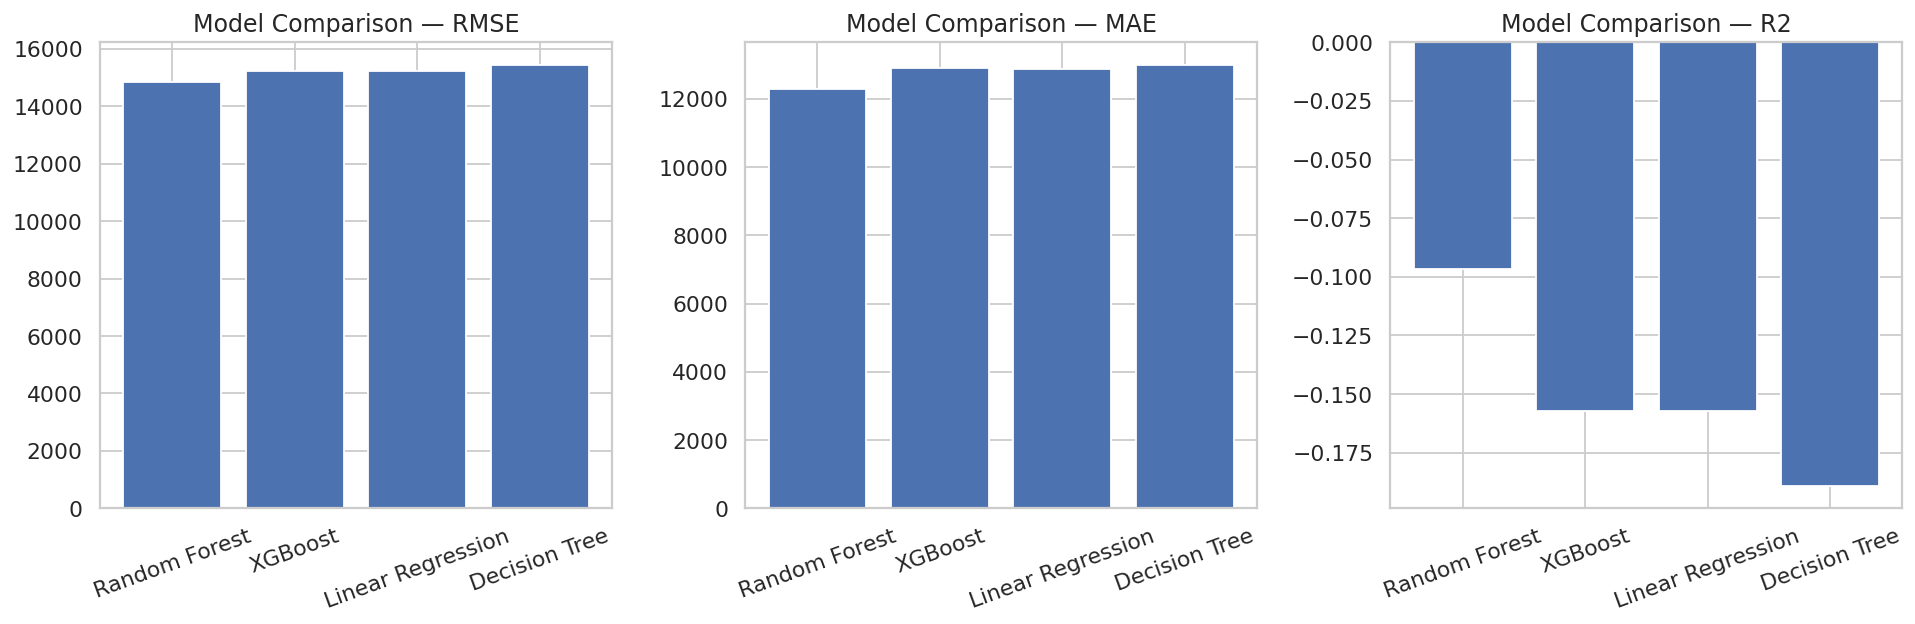


Best model: Random Forest


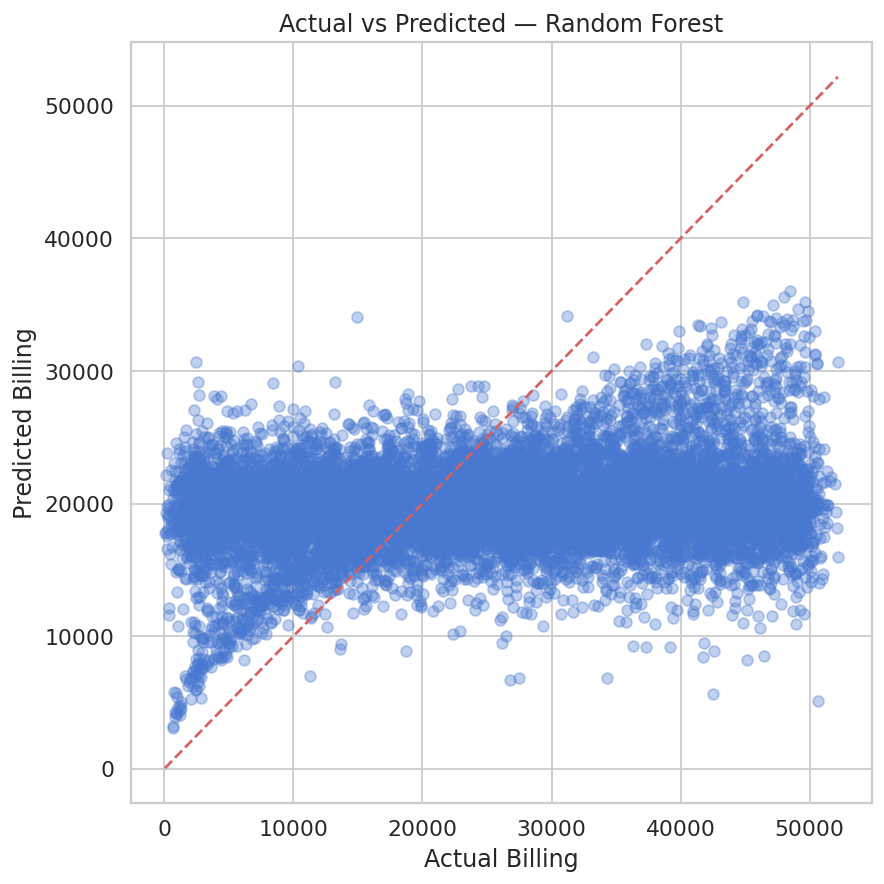

✓ Saved regression_model_comparison.csv


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 7 — BILLING AMOUNT PREDICTION
# Works from df_raw — does NOT modify the shared dataframe
# ─────────────────────────────────────────────────────────────
df_bill = df_raw.copy()

# Feature engineering
df_bill['Date of Admission'] = pd.to_datetime(df_bill['Date of Admission'], errors='coerce')
df_bill['Discharge Date']    = pd.to_datetime(df_bill['Discharge Date'],    errors='coerce')
df_bill['Length_of_Stay']    = (df_bill['Discharge Date'] - df_bill['Date of Admission']).dt.days.clip(lower=0)
df_bill['Admission_Month']   = df_bill['Date of Admission'].dt.month
df_bill['Admission_Year']    = df_bill['Date of Admission'].dt.year
df_bill['Admission_DayOfWeek'] = df_bill['Date of Admission'].dt.dayofweek
df_bill['Is_Weekend']        = df_bill['Admission_DayOfWeek'].isin([5,6]).astype(int)
df_bill['Age_Group']         = pd.cut(df_bill['Age'], bins=[0,18,35,50,65,120],
                                      labels=['0-18','19-35','36-50','51-65','65+']).astype(str)
df_bill['Age_x_LOS']         = df_bill['Age'] * df_bill['Length_of_Stay']
df_bill['Long_Stay_Flag']    = (df_bill['Length_of_Stay'] >= 7).astype(int)

# Strip string columns
for col in df_bill.select_dtypes('object').columns:
    df_bill[col] = df_bill[col].astype(str).str.strip()

# Target
target = 'Billing Amount'
df_bill[target] = pd.to_numeric(df_bill[target], errors='coerce')
df_bill = df_bill.dropna(subset=[target])
df_bill = df_bill[df_bill[target] >= 0]

# Drop columns not used as features
drop_cols  = ['Name','Doctor','Hospital','Room Number','Date of Admission','Discharge Date']
feature_cols_bill = [c for c in df_bill.columns if c not in drop_cols + [target]]
X_bill = df_bill[feature_cols_bill].copy()
y_bill = df_bill[target].copy()
y_log  = np.log1p(y_bill)

print(f'Features : {len(feature_cols_bill)}')
print(f'Samples  : {len(X_bill):,}')
print()

X_tr, X_te, y_tr, y_te, y_tr_orig, y_te_orig = train_test_split(
    X_bill, y_log, y_bill, test_size=0.2, random_state=42)

num_f = X_tr.select_dtypes(include=['int64','float64']).columns.tolist()
cat_f = X_tr.select_dtypes(include=['object','category']).columns.tolist()

num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', RobustScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                     ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))])
pre = ColumnTransformer([('num', num_pipe, num_f), ('cat', cat_pipe, cat_f)])

def eval_reg(name, ypred_log, y_true):
    ypred = np.maximum(np.expm1(ypred_log), 0)
    return {'Model':name,
            'MAE':  round(mean_absolute_error(y_true, ypred), 2),
            'RMSE': round(np.sqrt(mean_squared_error(y_true, ypred)), 2),
            'R2':   round(r2_score(y_true, ypred), 4)}, ypred

reg_results = {}; reg_preds = {}; reg_models = {}

# Linear Regression
lr_reg = Pipeline([('pre',pre),('m',LinearRegression())])
lr_reg.fit(X_tr,y_tr); sc,pr = eval_reg('Linear Regression', lr_reg.predict(X_te), y_te_orig)
reg_results['Linear Regression']=sc; reg_preds['Linear Regression']=pr; reg_models['Linear Regression']=lr_reg

# Decision Tree
dt_reg = Pipeline([('pre',pre),('m',DecisionTreeRegressor(max_depth=12,min_samples_split=20,min_samples_leaf=10,random_state=42))])
dt_reg.fit(X_tr,y_tr); sc,pr = eval_reg('Decision Tree', dt_reg.predict(X_te), y_te_orig)
reg_results['Decision Tree']=sc; reg_preds['Decision Tree']=pr; reg_models['Decision Tree']=dt_reg

# Random Forest
rf_reg = Pipeline([('pre',pre),('m',RandomForestRegressor(random_state=42,n_jobs=-1))])
rf_search = RandomizedSearchCV(rf_reg,
    {'m__n_estimators':[300,500],'m__max_depth':[10,15,None],'m__min_samples_split':[2,5],'m__max_features':['sqrt','log2']},
    n_iter=10, scoring='neg_root_mean_squared_error', cv=3, random_state=42, n_jobs=-1, verbose=0)
rf_search.fit(X_tr,y_tr); rf_reg=rf_search.best_estimator_
sc,pr = eval_reg('Random Forest', rf_reg.predict(X_te), y_te_orig)
reg_results['Random Forest']=sc; reg_preds['Random Forest']=pr; reg_models['Random Forest']=rf_reg
print('Best RF params:', rf_search.best_params_)

# XGBoost
xgb_reg = Pipeline([('pre',pre),('m',XGBRegressor(objective='reg:squarederror',tree_method='hist',eval_metric='rmse',random_state=42))])
xgb_search = RandomizedSearchCV(xgb_reg,
    {'m__n_estimators':[500,800],'m__learning_rate':[0.01,0.05,0.08],'m__max_depth':[4,6],'m__subsample':[0.8,1.0]},
    n_iter=10, scoring='neg_root_mean_squared_error', cv=3, random_state=42, n_jobs=1, verbose=0)
xgb_search.fit(X_tr,y_tr); xgb_reg=xgb_search.best_estimator_
sc,pr = eval_reg('XGBoost', xgb_reg.predict(X_te), y_te_orig)
reg_results['XGBoost']=sc; reg_preds['XGBoost']=pr; reg_models['XGBoost']=xgb_reg
print('Best XGB params:', xgb_search.best_params_)

# Results table
results_billing_df = pd.DataFrame(reg_results.values()).sort_values('RMSE')
print('\nModel Comparison:')
print(results_billing_df.to_string(index=False))

# Comparison charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, ['RMSE','MAE','R2']):
    ax.bar(results_billing_df['Model'], results_billing_df[metric], color=ACCENT, edgecolor='white')
    ax.set_title(f'Model Comparison — {metric}'); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.savefig('bill_model_comparison.png', bbox_inches='tight'); plt.show()

# Actual vs Predicted (best model)
best_bill_name = results_billing_df.iloc[0]['Model']
best_bill_pred = reg_preds[best_bill_name]
print(f'\nBest model: {best_bill_name}')
fig, ax = plt.subplots(figsize=(7,7))
ax.scatter(y_te_orig, best_bill_pred, alpha=0.35)
ax.plot([y_te_orig.min(),y_te_orig.max()],[y_te_orig.min(),y_te_orig.max()],'r--')
ax.set(xlabel='Actual Billing',ylabel='Predicted Billing',title=f'Actual vs Predicted — {best_bill_name}')
plt.tight_layout(); plt.savefig('bill_actual_vs_pred.png', bbox_inches='tight'); plt.show()

# Save billing model outputs
results_billing_df.to_csv('regression_model_comparison.csv', index=False)
print('✓ Saved regression_model_comparison.csv')


## Project Topic 2: Patient Risk Classification

Threshold 3 → High Risk: 68.0%
Threshold 4 → High Risk: 49.2%
Threshold 5 → High Risk: 29.8%
Threshold 6 → High Risk: 14.7%

✓ Risk Label set (threshold=4) — High:49.2%  Low:50.8%

✓ Train: (43972, 39)  |  Test: (10994, 39)
  Missing — train: 0  test: 0

  MODEL COMPARISON
              Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
Logistic Regression     0.741      0.733   0.744     0.738    0.793
      Random Forest     0.768      0.757   0.779     0.768    0.819
            XGBoost     0.752      0.727   0.791     0.758    0.794


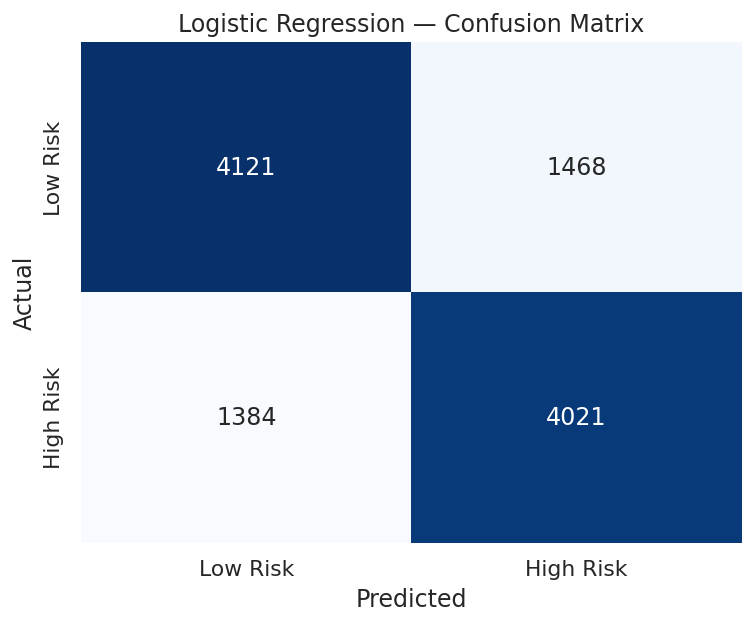

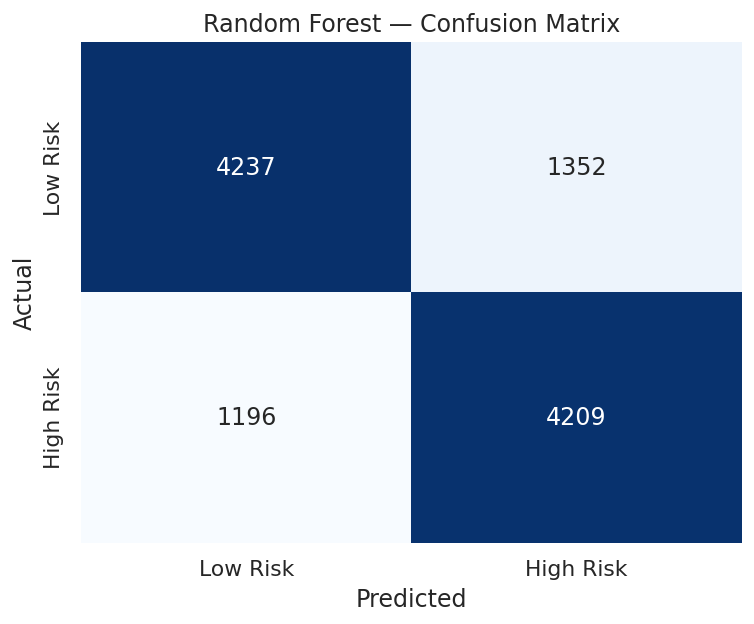

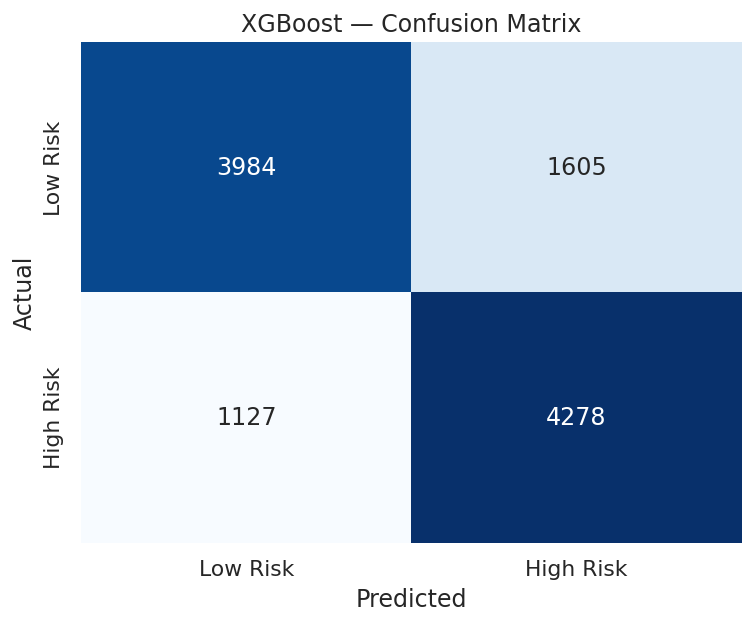

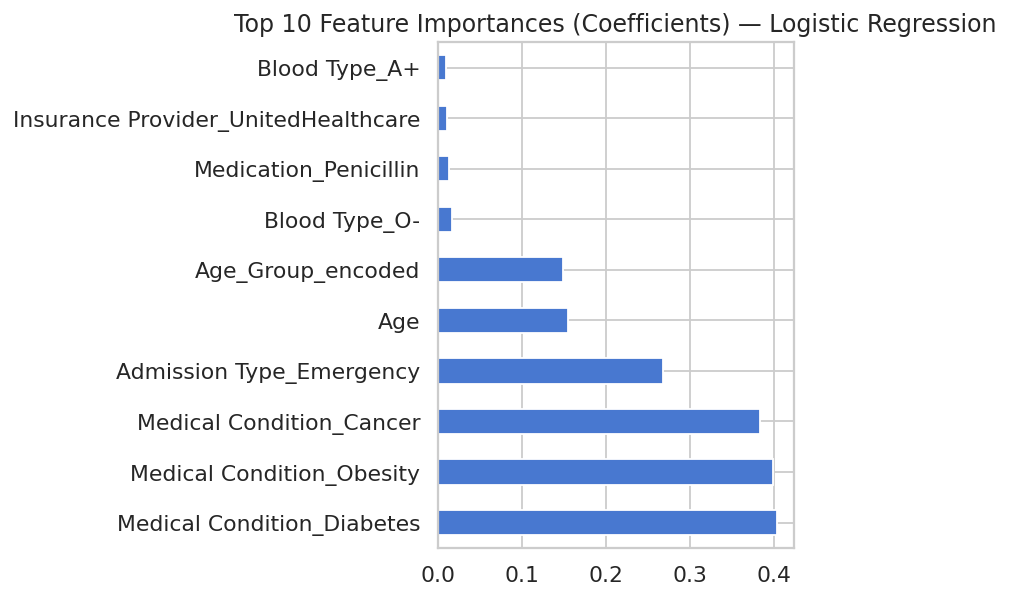

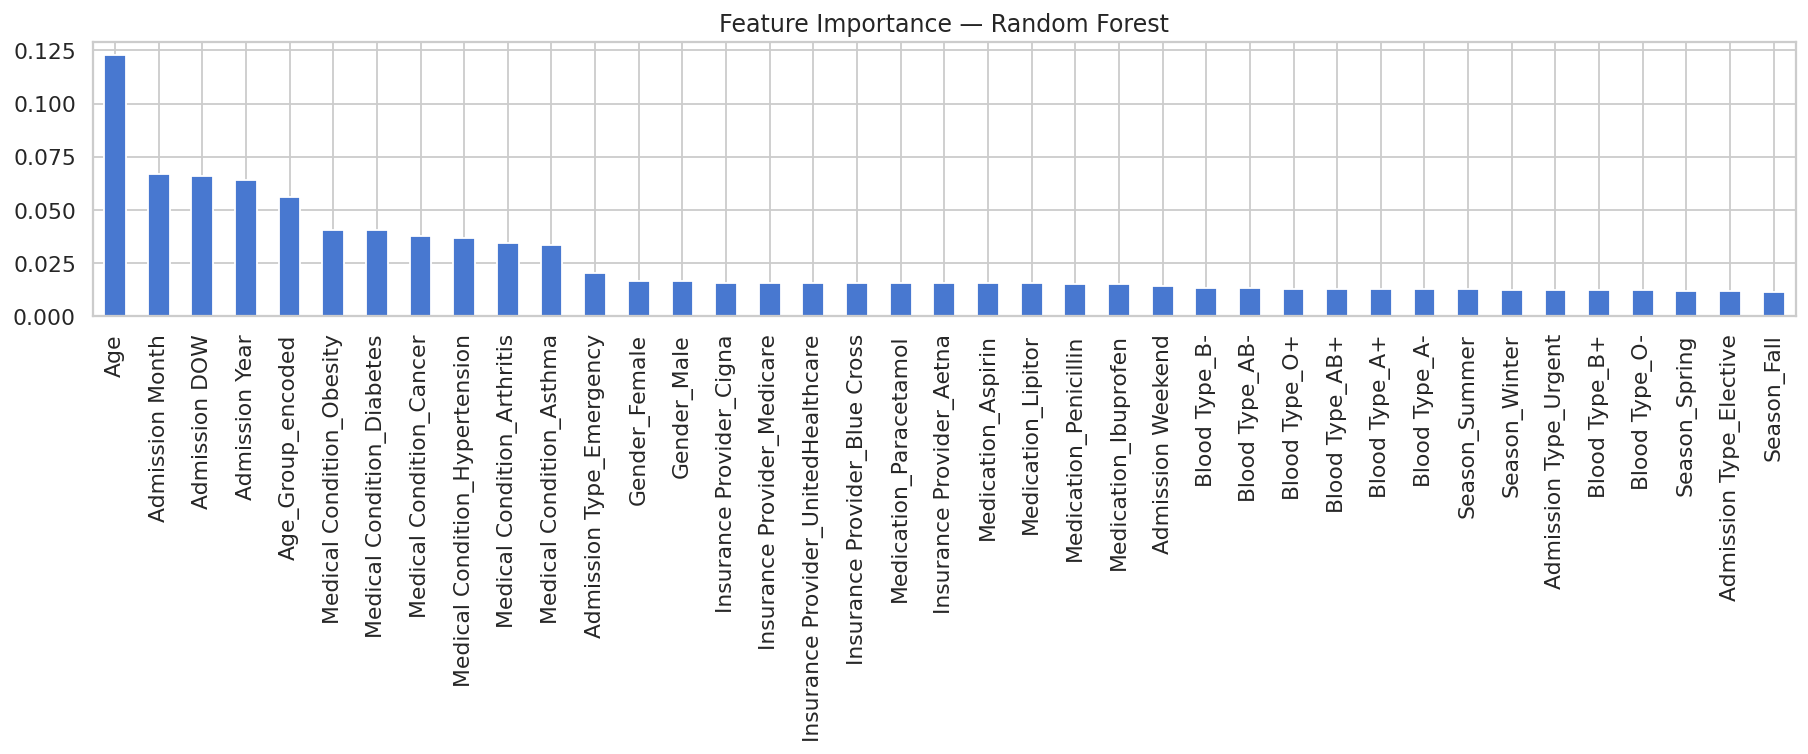

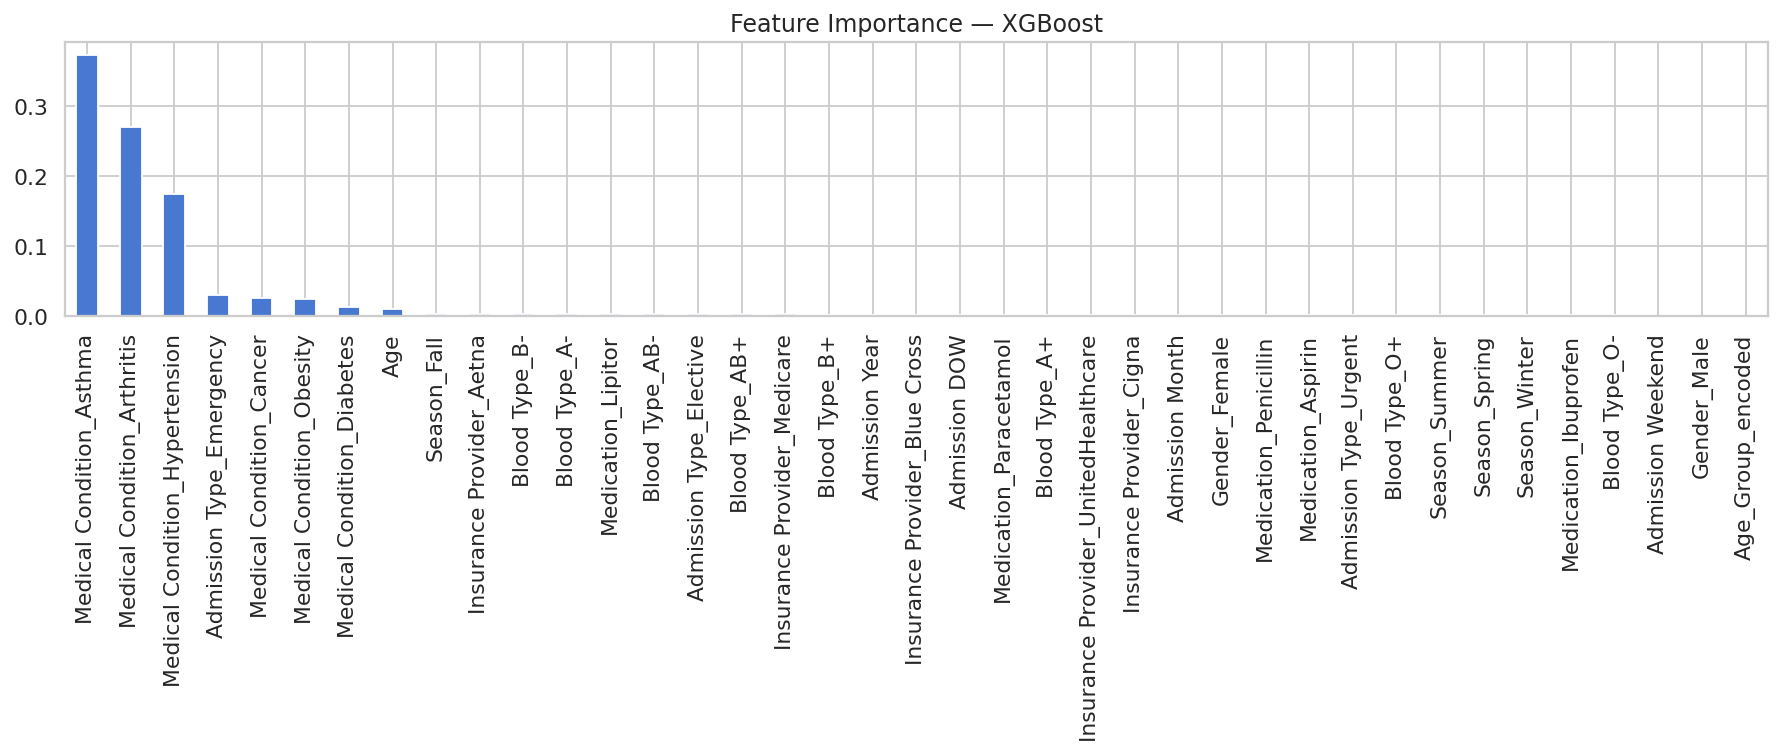

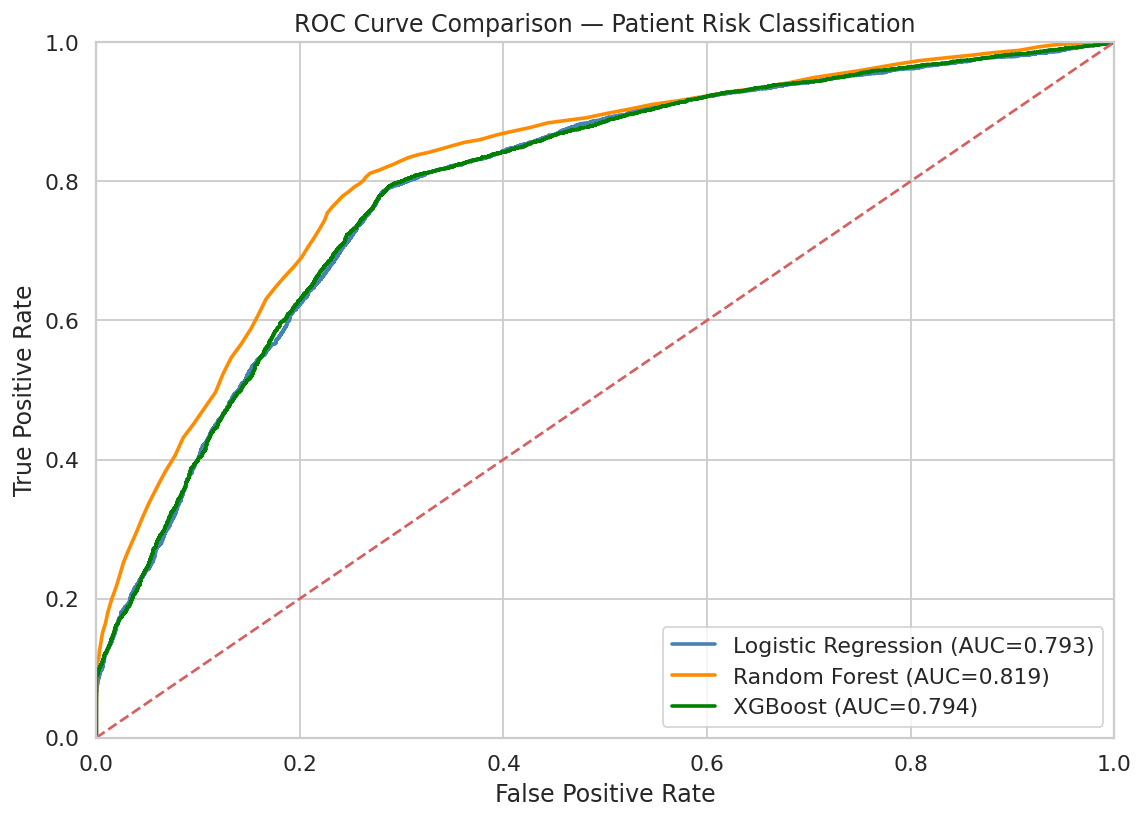


✓ Saved classification_model_comparison.csv


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 8 — PATIENT RISK CLASSIFICATION
# Works from df_raw — does NOT modify the shared dataframe
# ─────────────────────────────────────────────────────────────
df_risk_raw = df_raw.copy()

# ── Feature engineering ───────────────────────────────────
df_risk_raw['Date of Admission'] = pd.to_datetime(df_risk_raw['Date of Admission'], errors='coerce')
df_risk_raw['Discharge Date']    = pd.to_datetime(df_risk_raw['Discharge Date'],    errors='coerce')
df_risk_raw['LOS']               = (df_risk_raw['Discharge Date'] - df_risk_raw['Date of Admission']).dt.days
df_risk_raw['Admission Month']   = df_risk_raw['Date of Admission'].dt.month
df_risk_raw['Admission Year']    = df_risk_raw['Date of Admission'].dt.year
df_risk_raw['Admission DOW']     = df_risk_raw['Date of Admission'].dt.dayofweek
df_risk_raw['Admission Weekend'] = df_risk_raw['Admission DOW'].isin([5,6]).astype(int)
seasons_map = {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
               6:'Summer',7:'Summer',8:'Summer',9:'Fall',10:'Fall',11:'Fall'}
df_risk_raw['Season'] = df_risk_raw['Date of Admission'].dt.month.map(seasons_map)
df_risk_raw['Age_Group'] = pd.cut(df_risk_raw['Age'],
    bins=[0,20,30,40,50,60,70,80,120],
    labels=['0-19','20-29','30-39','40-49','50-59','60-69','70-79','80+'],
    right=False, include_lowest=True)

# ── Risk label engineering ─────────────────────────────────
los_thr     = df_risk_raw['LOS'].median()
billing_thr = df_risk_raw['Billing Amount'].quantile(0.75)
age_thr     = df_risk_raw['Age'].quantile(0.75)
df_risk_raw['Test Results_encoded'] = df_risk_raw['Test Results'].map({'Normal':0,'Inconclusive':1,'Abnormal':2})
df_risk_raw['flag_long_stay']        = (df_risk_raw['LOS'] > los_thr).astype(int)
df_risk_raw['flag_abnormal_result']  = (df_risk_raw['Test Results_encoded'] == 2).astype(int)
df_risk_raw['flag_high_billing']     = (df_risk_raw['Billing Amount'] > billing_thr).astype(int)
df_risk_raw['flag_high_age']         = (df_risk_raw['Age'] > age_thr).astype(int)
df_risk_raw['flag_emergency']        = (df_risk_raw['Admission Type'] == 'Emergency').astype(int)
df_risk_raw['flag_complex_condition']= df_risk_raw['Medical Condition'].isin(['Cancer','Diabetes','Obesity']).astype(int)
df_risk_raw['risk_score'] = (
    df_risk_raw['flag_long_stay']         * 2 +
    df_risk_raw['flag_abnormal_result']   * 2 +
    df_risk_raw['flag_complex_condition'] * 2 +
    df_risk_raw['flag_high_billing']      * 1 +
    df_risk_raw['flag_high_age']          * 1 +
    df_risk_raw['flag_emergency']         * 1
)
for thr in [3,4,5,6]:
    pct = (df_risk_raw['risk_score'] >= thr).mean() * 100
    print(f'Threshold {thr} → High Risk: {pct:.1f}%')
df_risk_raw['Risk Label'] = (df_risk_raw['risk_score'] >= 4).astype(int)
print(f'\n✓ Risk Label set (threshold=4) — High:{df_risk_raw["Risk Label"].mean()*100:.1f}%  Low:{(1-df_risk_raw["Risk Label"].mean())*100:.1f}%')

# ── Feature matrix ─────────────────────────────────────────
feat_cols = ['Age','Age_Group','Gender','Blood Type','Medical Condition',
             'Season','Insurance Provider','Admission Type','Medication',
             'Admission Month','Admission Year','Admission DOW','Admission Weekend']
X = df_risk_raw[feat_cols].copy()
y = df_risk_raw['Risk Label'].copy()

# ── Train/test split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ── Encode ─────────────────────────────────────────────────
ohe_cols = ['Gender','Blood Type','Medical Condition','Insurance Provider','Medication','Season','Admission Type']
encoder  = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe_tr   = pd.DataFrame(encoder.fit_transform(X_train[ohe_cols]),
                         columns=encoder.get_feature_names_out(ohe_cols), index=X_train.index)
ohe_te   = pd.DataFrame(encoder.transform(X_test[ohe_cols]),
                         columns=encoder.get_feature_names_out(ohe_cols), index=X_test.index)
age_ord  = {'0-19':0,'20-29':1,'30-39':2,'40-49':3,'50-59':4,'60-69':5,'70-79':6,'80+':7}
num_cols = ['Age','Admission Month','Admission Year','Admission DOW','Admission Weekend']
X_tr_enc = pd.concat([X_train[num_cols].reset_index(drop=True), ohe_tr.reset_index(drop=True)], axis=1)
X_tr_enc['Age_Group_encoded'] = X_train['Age_Group'].map(age_ord).values
X_te_enc = pd.concat([X_test[num_cols].reset_index(drop=True),  ohe_te.reset_index(drop=True)], axis=1)
X_te_enc['Age_Group_encoded'] = X_test['Age_Group'].map(age_ord).values

# ── Scale ──────────────────────────────────────────────────
scaler       = StandardScaler()
X_tr_scaled  = pd.DataFrame(scaler.fit_transform(X_tr_enc), columns=X_tr_enc.columns)
X_te_scaled  = pd.DataFrame(scaler.transform(X_te_enc),     columns=X_te_enc.columns)
print(f'\n✓ Train: {X_tr_scaled.shape}  |  Test: {X_te_scaled.shape}')
print(f'  Missing — train: {X_tr_scaled.isnull().sum().sum()}  test: {X_te_scaled.isnull().sum().sum()}')

# ── Helper ─────────────────────────────────────────────────
def clf_metrics(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    pred  = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]
    fpr,tpr,_ = roc_curve(yte, proba)
    return {'name':name,'model':model,'y_pred':pred,'y_proba':proba,
            'Accuracy':round(accuracy_score(yte,pred),3),
            'Precision':round(precision_score(yte,pred),3),
            'Recall':round(recall_score(yte,pred),3),
            'F1 Score':round(f1_score(yte,pred),3),
            'ROC AUC':round(roc_auc_score(yte,proba),3),
            'FPR':fpr,'TPR':tpr}

clf = {}
clf['LR']  = clf_metrics('Logistic Regression', LogisticRegression(max_iter=1000,random_state=42),
                          X_tr_scaled,y_train,X_te_scaled,y_test)
clf['RF']  = clf_metrics('Random Forest',        RandomForestClassifier(n_estimators=100,random_state=42),
                          X_tr_scaled,y_train,X_te_scaled,y_test)
clf['XGB'] = clf_metrics('XGBoost',              XGBClassifier(n_estimators=100,max_depth=5,learning_rate=0.1,verbosity=0,eval_metric='logloss'),
                          X_tr_scaled,y_train,X_te_scaled,y_test)

metric_cols_clf = ['Model','Accuracy','Precision','Recall','F1 Score','ROC AUC']
comparison_clf  = pd.DataFrame([{'Model':r['name'],**{k:r[k] for k in ['Accuracy','Precision','Recall','F1 Score','ROC AUC']}} for r in clf.values()])
print('\n' + '='*55)
print('  MODEL COMPARISON')
print('='*55)
print(comparison_clf.to_string(index=False))

# ── Individual confusion matrices ──────────────────────────
for key, r in clf.items():
    cm = confusion_matrix(y_test, r['y_pred'])
    fig, ax = plt.subplots(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False,
                xticklabels=['Low Risk','High Risk'], yticklabels=['Low Risk','High Risk'], ax=ax)
    ax.set(title=f'{r["name"]} — Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    plt.tight_layout()
    plt.savefig(f'{key.lower()}_cm.png', dpi=300, bbox_inches='tight'); plt.show()

# ── Feature importance charts ──────────────────────────────
lr_model = clf['LR']['model']
coefs = pd.Series(lr_model.coef_[0], index=X_tr_scaled.columns)
coefs.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (Coefficients) — Logistic Regression')
plt.tight_layout(); plt.savefig('log_features.png', dpi=300, bbox_inches='tight'); plt.show()

rf_model = clf['RF']['model']
rf_imp   = pd.Series(rf_model.feature_importances_, index=X_tr_scaled.columns).sort_values(ascending=False)
rf_imp.plot(kind='bar', figsize=(14,6))
plt.title('Feature Importance — Random Forest')
plt.tight_layout(); plt.savefig('rf_features.png', dpi=300, bbox_inches='tight'); plt.show()

xgb_model = clf['XGB']['model']
xgb_imp   = pd.Series(xgb_model.feature_importances_, index=X_tr_scaled.columns).sort_values(ascending=False)
xgb_imp.plot(kind='bar', figsize=(14,6))
plt.title('Feature Importance — XGBoost')
plt.tight_layout(); plt.savefig('xgb_features.png', dpi=300, bbox_inches='tight'); plt.show()

# ── Combined ROC curve ─────────────────────────────────────
colors_clf = {'Logistic Regression':'steelblue','Random Forest':'darkorange','XGBoost':'green'}
fig, ax = plt.subplots(figsize=(9,6.5))
for r in clf.values():
    ax.plot(r['FPR'],r['TPR'],label=f"{r['name']} (AUC={r['ROC AUC']:.3f})",
            color=colors_clf[r['name']],linewidth=2)
ax.plot([0,1],[0,1],'r--',linewidth=1.5)
ax.set(xlabel='False Positive Rate',ylabel='True Positive Rate',
       title='ROC Curve Comparison — Patient Risk Classification',xlim=[0,1],ylim=[0,1])
ax.legend(loc='lower right')
plt.tight_layout(); plt.savefig('combined_roc.png', dpi=300, bbox_inches='tight'); plt.show()

comparison_clf.to_csv('classification_model_comparison.csv', index=False)
print('\n✓ Saved classification_model_comparison.csv')


## Power BI Export — Build Dashboard-Ready CSVs

In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 9 — BUILD & SAVE POWER BI EXPORT DATAFRAMES
# ─────────────────────────────────────────────────────────────

# Re-encode full dataset for predictions
ohe_all  = pd.DataFrame(encoder.transform(df_risk_raw[feat_cols][ohe_cols]),
                         columns=encoder.get_feature_names_out(ohe_cols),
                         index=df_risk_raw.index)
X_all_enc = pd.concat([df_risk_raw[num_cols].reset_index(drop=True),
                        ohe_all.reset_index(drop=True)], axis=1)
X_all_enc['Age_Group_encoded'] = df_risk_raw['Age_Group'].map(age_ord).values
X_all_scaled = pd.DataFrame(scaler.transform(X_all_enc), columns=X_all_enc.columns)

df_risk_raw['RF_Predicted_Risk']    = clf['RF']['model'].predict(X_all_scaled)
df_risk_raw['RF_Risk_Probability']  = clf['RF']['model'].predict_proba(X_all_scaled)[:,1].round(4)
df_risk_raw['XGB_Predicted_Risk']   = clf['XGB']['model'].predict(X_all_scaled)
df_risk_raw['XGB_Risk_Probability'] = clf['XGB']['model'].predict_proba(X_all_scaled)[:,1].round(4)

# Page 1: Financial Analysis
df_pbi_financial = df_fin[[
    'Age','Age_Group','Medical_Condition','Admission_Type',
    'Insurance_Provider','Gender','Blood_Type','Medication',
    'Length_Of_Stay','Billing_Amount'
]].copy()

# Page 2: Patient Risk
df_pbi_risk = df_risk_raw[[
    'Age','Age_Group','Medical Condition','Admission Type',
    'Insurance Provider','Gender','LOS','Billing Amount','Season','Test Results',
    'risk_score','Risk Label','RF_Predicted_Risk','RF_Risk_Probability',
    'XGB_Predicted_Risk','XGB_Risk_Probability',
    'flag_long_stay','flag_abnormal_result','flag_high_billing',
    'flag_high_age','flag_emergency','flag_complex_condition'
]].copy()
df_pbi_risk.columns = [c.replace(' ','_') for c in df_pbi_risk.columns]

# Feature importance (all 3 models combined for Power BI slicer)
df_pbi_feat = pd.concat([
    pd.DataFrame({'Feature':rf_imp.index,  'Importance':rf_imp.values.round(4),  'Model':'Random Forest'}),
    pd.DataFrame({'Feature':xgb_imp.index, 'Importance':xgb_imp.values.round(4), 'Model':'XGBoost'}),
    pd.DataFrame({'Feature':coefs.sort_values(ascending=False).index,
                  'Importance':coefs.sort_values(ascending=False).abs().values.round(4),
                  'Model':'Logistic Regression'}),
], ignore_index=True)

# Regression results
df_pbi_reg = results_billing_df.copy()

# Save all to Drive
exports = {
    'financial_analysis.csv'      : df_pbi_financial,
    'patient_risk.csv'            : df_pbi_risk,
    'feature_importance.csv'      : df_pbi_feat,
    'classification_results.csv'  : comparison_clf,
    'regression_results.csv'      : df_pbi_reg,
}

for filename, df_out in exports.items():
    path = os.path.join(DRIVE_OUTPUT_PATH, filename)
    df_out.to_csv(path, index=False)
    print(f'✓ {filename} ({len(df_out):,} rows) → {path}')

# Also copy chart PNGs to Drive
charts_drive = os.path.join(DRIVE_OUTPUT_PATH, 'charts')
os.makedirs(charts_drive, exist_ok=True)
for f in os.listdir('.'):
    if f.endswith('.png'):
        shutil.copy(f, os.path.join(charts_drive, f))
        print(f'✓ {f} → {charts_drive}')

print(f'\n✓ All outputs saved to: {DRIVE_OUTPUT_PATH}')


✓ financial_analysis.csv (54,966 rows) → /content/gdrive/MyDrive/capstone_outputs/financial_analysis.csv
✓ patient_risk.csv (54,966 rows) → /content/gdrive/MyDrive/capstone_outputs/patient_risk.csv
✓ feature_importance.csv (117 rows) → /content/gdrive/MyDrive/capstone_outputs/feature_importance.csv
✓ classification_results.csv (3 rows) → /content/gdrive/MyDrive/capstone_outputs/classification_results.csv
✓ regression_results.csv (4 rows) → /content/gdrive/MyDrive/capstone_outputs/regression_results.csv
✓ xgb_cm.png → /content/gdrive/MyDrive/capstone_outputs/charts
✓ 04_heatmap.png → /content/gdrive/MyDrive/capstone_outputs/charts
✓ 01_univariate.png → /content/gdrive/MyDrive/capstone_outputs/charts
✓ lr_cm.png → /content/gdrive/MyDrive/capstone_outputs/charts
✓ xgb_features.png → /content/gdrive/MyDrive/capstone_outputs/charts
✓ bill_actual_vs_pred.png → /content/gdrive/MyDrive/capstone_outputs/charts
✓ fin_05_los_billing.png → /content/gdrive/MyDrive/capstone_outputs/charts
✓ bill_mod

## Power BI Dashboard Embed
Run this cell **after** publishing your `.pbix` to `app.powerbi.com` and filling in the IDs in Cell 2.

In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 10 — EMBED POWER BI DASHBOARD
# Requires POWERBI_GROUP_ID and POWERBI_REPORT_ID in Cell 2
# ─────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────
# CELL 10 — DISPLAY POWER BI DASHBOARD LINK
# ─────────────────────────────────────────────────────────────
from IPython.display import display, HTML

dashboard_url = f"https://app.powerbi.com/groups/{POWERBI_GROUP_ID}/reports/{POWERBI_REPORT_ID}"

display(HTML(f"""
<div style="font-family: Arial, sans-serif; max-width: 700px;">

    <div style="background:#1B3A6B; padding:16px 24px; border-radius:6px 6px 0 0;">
        <h2 style="color:white; margin:0; font-size:18px;">
            Healthcare Analytics Capstone
        </h2>
        <p style="color:#D5E8F0; margin:4px 0 0 0; font-size:13px;">
            Wildcats Analytics Partners  |  Northwestern MSDS
        </p>
    </div>

    <div style="background:#D5E8F0; padding:20px 24px; border-left:4px solid #2E75B6;">
        <p style="margin:0 0 14px 0; color:#1B3A6B; font-weight:bold; font-size:15px;">
            Power BI Dashboard — Ready to View
        </p>
        <a href="{dashboard_url}" target="_blank"
           style="display:inline-block; background:#2E75B6; color:white;
                  padding:12px 28px; border-radius:4px; text-decoration:none;
                  font-weight:bold; font-size:15px; letter-spacing:0.3px;">
            Open Dashboard in Power BI &#8599;
        </a>
        <p style="margin:14px 0 0 0; color:#555; font-size:12px;">
            Opens in a new tab. Sign in with your Northwestern account if prompted.
        </p>
    </div>

    <div style="background:#f8f8f8; padding:14px 24px; border:1px solid #ddd;
                border-radius:0 0 6px 6px;">
        <p style="margin:0; color:#666; font-size:12px;">
            <strong>Report ID:</strong> {POWERBI_REPORT_ID} &nbsp;|&nbsp;
            <strong>Workspace:</strong> My Workspace
        </p>
    </div>

</div>
"""))
